In [1]:
import scanpy as sc
#原始数据分群
import pandas as pd
import numpy as np
# 读取数据，第一列为基因名，第一行为细胞名
df = pd.read_csv('/mnt/md0/luying/ribo/dnabert/DNABERT/examples/my_project/predicted_expression_421_11619_250504s123.csv')

# 设置基因名为索引
df.set_index('Unnamed: 0', inplace=True)

# 构建 AnnData 对象（行为细胞，列为基因，需要转置）
adata_sc1 = sc.AnnData(df)


meta = pd.read_csv('/mnt/md0/luying/ribo/dnabert/DNABERT/examples/my_project/data/GSE162060_HEK293Tscriboseq_meta.csv')

adata_sc1.obs['cell_type'] = meta['seurat_clusters'].values

adata_sc1.obs['cell_type'] = adata_sc1.obs['cell_type'].astype('category')

import numpy as np

# 删除包含 NaN 的基因（var）
adata_sc1 = adata_sc1[:, ~np.isnan(adata_sc1.X).any(axis=0)].copy()


In [2]:
meta.head()

,Unnamed: 0,CB,well,plate,cds,utr3,utr5,cds_frac,cell_total,fraction,seurat_clusters,UMAP_1,UMAP_2
0,HEK293T-Starv1_AACCACGTCA,AACCACGTCA,M6,HEK293T-Starv1,7417,447,803,0.855775,8667,Arg6h,0,3.400233,-0.482453
1,HEK293T-Starv1_AACCGTAACA,AACCGTAACA,D11,HEK293T-Starv1,7411,524,534,0.875074,8469,Leu3h,1,-3.603868,-1.694647
2,HEK293T-Starv1_AACCTAGACG,AACCTAGACG,P5,HEK293T-Starv1,14252,751,1319,0.873177,16322,Arg3h,1,-4.941925,-0.750750
3,HEK293T-Starv1_AACGCGGTAG,AACGCGGTAG,O7,HEK293T-Starv1,14512,605,1174,0.890799,16291,Arg6h,0,4.527219,-0.822223
4,HEK293T-Starv1_AACTCTACCG,AACTCTACCG,D14,HEK293T-Starv1,2541,363,340,0.783292,3244,Leu3h,0,-0.060543,-1.761378


In [ ]:
# # 选择高变基因
# sc.pp.highly_variable_genes(adata_sc1, n_top_genes=4000)  # 选择高变基因


# #adata_sc1 = adata_sc1[:, adata_sc1.var['highly_variable']]  # 仅保留高变基因

# # 运行 PCA 降维 
# sc.tl.pca(adata_sc1, n_comps=50)
# # 运行邻居图
# sc.pp.neighbors(adata_sc1, n_neighbors=15, n_pcs=50)
# # 运行 UMAP 降维
# sc.tl.umap(adata_sc1, min_dist=0.1)

# # 绘制 UMAP 图
# sc.pl.umap(adata_sc1, title='UMAP of Cells', color='cell_type')

In [3]:
import pandas as pd

# 读取包含坐标和cluster信息的CSV
clusters_df = pd.read_csv("data/proteinpridict_umap_clusters.csv", index_col=0)


# 确保索引（细胞名）对齐
common_cells = adata_sc1.obs_names.intersection(clusters_df.index)

# 只保留两个对象中共有的细胞
adata_sc1 = adata_sc1[common_cells].copy()
clusters_df = clusters_df.loc[common_cells]

# 将对应的坐标和cluster列赋值到 adata_sc.obs 中
adata_sc1.obs["UMAP_1"] = clusters_df["UMAP_1"].values
adata_sc1.obs["UMAP_2"] = clusters_df["UMAP_2"].values
adata_sc1.obs["seurat_clusters"] = clusters_df["seurat_clusters"].astype(str).values
adata_sc1.obs["seurat_clusters2"] = clusters_df["seurat_clusters2"].astype(str).values




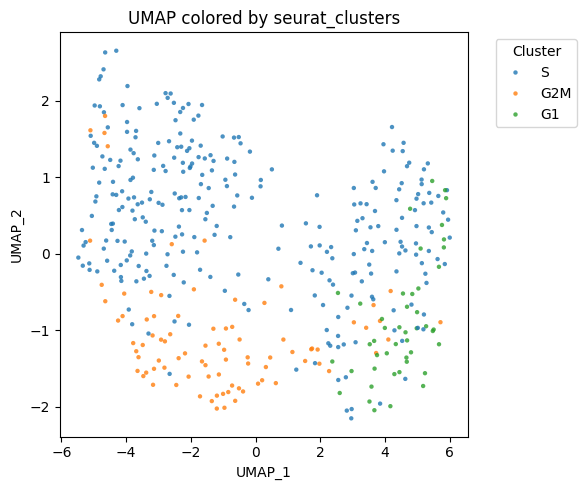

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 创建一个新图
plt.figure(figsize=(6, 5))

# 绘制散点图，用 seurat_clusters 上色
sns.scatterplot(
    x=adata_sc1.obs["UMAP_1"],
    y=adata_sc1.obs["UMAP_2"],
    hue=adata_sc1.obs["seurat_clusters2"],
    palette="tab10",  # 可改为其他调色板，如 "Set2"、"Spectral"
    s=10,              # 点的大小
    linewidth=0,
    alpha=0.8
)

plt.title("UMAP colored by seurat_clusters")
plt.xlabel("UMAP_1")
plt.ylabel("UMAP_2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Cluster")
plt.tight_layout()
plt.show()



In [3]:
# 下载或手动定义 Seurat 的人类 cell cycle gene 列表
# 你也可以从 Seurat 的 cc.genes$S 和 cc.genes$G2M 拷贝过来
s_genes = [
'ENST00000216122','ENST00000382011','ENST00000416905','ENST00000417343','ENST00000444778','ENST00000451351','ENST00000464908','ENST00000465557','ENST00000493076','ENST00000493569','ENST00000379143','ENST00000379160','ENST00000323224','ENST00000323250','ENST00000323274','ENST00000579128','ENST00000581920','ENST00000584122','ENST00000305885','ENST00000535307','ENST00000535723','ENST00000265056','ENST00000468414','ENST00000468659','ENST00000472731','ENST00000473785','ENST00000474964','ENST00000477668','ENST00000480910','ENST00000491422','ENST00000262105','ENST00000517709','ENST00000518221','ENST00000518382','ENST00000518680','ENST00000519138','ENST00000519170','ENST00000519470','ENST00000520637','ENST00000520994','ENST00000521151','ENST00000521261','ENST00000523853','ENST00000524086','ENST00000647877','ENST00000648407','ENST00000648519','ENST00000648533','ENST00000648554','ENST00000649838','ENST00000649919','ENST00000649973','ENST00000650216','ENST00000650327','ENST00000697120','ENST00000697121','ENST00000697122','ENST00000697123','ENST00000300738','ENST00000526304','ENST00000526350','ENST00000526865','ENST00000528442','ENST00000528470','ENST00000529109','ENST00000530368','ENST00000531591','ENST00000532170','ENST00000532710','ENST00000533349','ENST00000533495','ENST00000534285','ENST00000242576','ENST00000336865','ENST00000446767','ENST00000539287','ENST00000540158','ENST00000699559','ENST00000699560','ENST00000699561','ENST00000699562','ENST00000699563','ENST00000699564',
              'ENST00000699565','ENST00000699566','ENST00000699567','ENST00000253462','ENST00000595355','ENST00000596233','ENST00000264156','ENST00000483902','ENST00000492091','ENST00000306721','ENST00000347703','ENST00000410019','ENST00000410101','ENST00000435616','ENST00000467411','ENST00000468359','ENST00000496441','ENST00000695901','ENST00000695911','ENST00000695912','ENST00000695913','ENST00000695914','ENST00000695918','ENST00000366991','ENST00000463791','ENST00000475419','ENST00000489149','ENST00000496442','ENST00000542077','ENST00000338193','ENST00000546761','ENST00000548173','ENST00000549549','ENST00000550224','ENST00000550770','ENST00000552408','ENST00000552590','ENST00000672280','ENST00000706566','ENST00000706567','ENST00000612630','ENST00000613817','ENST00000615884','ENST00000616255','ENST00000620565','ENST00000622802','ENST00000624301','ENST00000650932','None','ENST00000348459','ENST00000371327','ENST00000371332','ENST00000394036','ENST00000394045','ENST00000419900','ENST00000462057','ENST00000464030','ENST00000466552','ENST00000475263','ENST00000630929','ENST00000698650','ENST00000698651','ENST00000698672','ENST00000698673','ENST00000698674','ENST00000698675','ENST00000698676','ENST00000698799','ENST00000698800','ENST00000698830','ENST00000055077','ENST00000352131','ENST00000463194','ENST00000470266','ENST00000473493','ENST00000479105','ENST00000480432','ENST00000485545','ENST00000491206','ENST00000493156','ENST00000494019','ENST00000497430','ENST00000621097','ENST00000313433','ENST00000373909','ENST00000373912','ENST00000419958','ENST00000444045','ENST00000350030','ENST00000351223','ENST00000372052','ENST00000437362','ENST00000437901','ENST00000453748','ENST00000464190','ENST00000470768','ENST00000472408','ENST00000481782','ENST00000525515','ENST00000527359','ENST00000527470','ENST00000527932','ENST00000528084','ENST00000528238','ENST00000529333','ENST00000530073','ENST00000530840','ENST00000531532','ENST00000531612','ENST00000534101','ENST00000534450','ENST00000537798','ENST00000629893','ENST00000228843','ENST00000352618','ENST00000398012','ENST00000442992','ENST00000535558','ENST00000536117','ENST00000536346','ENST00000536886','ENST00000538817','ENST00000544029','ENST00000544110','ENST00000544173','ENST00000544927','ENST00000544931','ENST00000230056','ENST00000356509','ENST00000378054','ENST00000378059','ENST00000468943','ENST00000476555','ENST00000620958','ENST00000263795','ENST00000381246','ENST00000452115','ENST00000478130','ENST00000318386','ENST00000429429','ENST00000480936','ENST00000483348','ENST00000488267','ENST00000489418','ENST00000308108','ENST00000396133','ENST00000517487','ENST00000519889','ENST00000520509','ENST00000521809','ENST00000523476','ENST00000524224','ENST00000013070','ENST00000553674','ENST00000553857','ENST00000554232','ENST00000555113','ENST00000555329','ENST00000556871','ENST00000263681','ENST00000524752','ENST00000527458','ENST00000528481','ENST00000530163','ENST00000530511','ENST00000531615','ENST00000532497','ENST00000532784','ENST00000532954','ENST00000233146','ENST00000406134','ENST00000467323','ENST00000543555','ENST00000644092','ENST00000644900','ENST00000645339','ENST00000645506','ENST00000646415','ENST00000287394','ENST00000517666','ENST00000519124','ENST00000521496','ENST00000521903','ENST00000530065','ENST00000534257','ENST00000550993','ENST00000267868','ENST00000382643','ENST00000423169','ENST00000525066','ENST00000526763','ENST00000527860','ENST00000531277','ENST00000532743','ENST00000533741','ENST00000557850','ENST00000645673','ENST00000304567','ENST00000360566','ENST00000381786',
              'ENST00000459969','ENST00000461327','ENST00000462343','ENST00000485717','ENST00000487591','ENST00000491447','ENST00000498343','ENST00000607140','ENST00000615152','ENST00000641198','ENST00000641498','ENST00000642996','ENST00000646978','ENST00000652660','ENST00000263201','ENST00000404724','ENST00000407835','ENST00000428937','ENST00000437685','ENST00000438587','ENST00000455750','ENST00000471470','ENST00000483431','ENST00000487669','ENST00000491520','ENST00000493724','ENST00000671972','ENST00000672837','ENST00000209728','ENST00000473555','ENST00000577249','ENST00000580824','ENST00000582402','ENST00000648633','ENST00000649662','ENST00000348581','ENST00000366548','ENST00000423131','ENST00000437497','ENST00000450748','ENST00000469419','ENST00000493702','ENST00000518483','ENST00000518741','ENST00000519225','ENST00000521202','ENST00000523590','ENST00000261881','ENST00000561773','ENST00000562124','ENST00000566524','ENST00000568216','ENST00000570251','ENST00000313655','ENST00000521795','ENST00000355112','ENST00000558599','ENST00000558825','ENST00000559282','ENST00000559426','ENST00000559724','ENST00000560136','ENST00000560509','ENST00000560559','ENST00000560821','ENST00000648453','ENST00000680772','ENST00000681142','ENST00000237177','ENST00000419040','ENST00000547893','ENST00000548224','ENST00000551025','ENST00000552401','ENST00000339950','ENST00000371146','ENST00000442679','ENST00000452143','ENST00000251195','ENST00000318121','ENST00000373220','ENST00000466308','ENST00000517467','ENST00000520551','ENST00000379059','ENST00000379068','ENST00000480125','ENST00000493342','ENST00000494204','ENST00000611764','ENST00000672178','ENST00000676703','ENST00000677083','ENST00000677890','ENST00000677939','ENST00000678249','ENST00000678847','ENST00000679301','ENST00000314103','ENST00000480486','ENST00000481458','ENST00000259008','ENST00000577598','ENST00000577913','ENST00000579028','ENST00000583837','ENST00000584322','ENST00000682066','ENST00000682073','ENST00000682369','ENST00000682433','ENST00000682453','ENST00000682477','ENST00000682589','ENST00000682611','ENST00000682755','ENST00000682989','ENST00000683039','ENST00000683235','ENST00000683381','ENST00000683535','ENST00000683672','ENST00000683692','ENST00000684471','ENST00000684584','ENST00000684626','ENST00000684769','ENST00000250024','ENST00000527884','ENST00000529188','ENST00000532666','ENST00000620009'
]

g2m_genes = [
'ENST00000296503','ENST00000438704','ENST00000446922','ENST00000506267','ENST00000511316','ENST00000316629','ENST00000373809','ENST00000395284','ENST00000448257','ENST00000475504','ENST00000487784','ENST00000519078','ENST00000519760','ENST00000260359','ENST00000414849','ENST00000450592','ENST00000557840','ENST00000558123','ENST00000558582','ENST00000559046','ENST00000559596','ENST00000559659','ENST00000560177','ENST00000560318','ENST00000560747','ENST00000560898','ENST00000668273','ENST00000243893','ENST00000335046','ENST00000352551','ENST00000356455','ENST00000372568','ENST00000405520','ENST00000496085','ENST00000617055','ENST00000301633','ENST00000350051','ENST00000374948','ENST00000586192','ENST00000587746','ENST00000589892','ENST00000590449','ENST00000590925','ENST00000591800','ENST00000592115','ENST00000592734','ENST00000300403','ENST00000340513','ENST00000423485','ENST00000577541','ENST00000577706','ENST00000578412','ENST00000581055','ENST00000261597','ENST00000574096','ENST00000574567','ENST00000575515','ENST00000576274','ENST00000314355','ENST00000271452','ENST00000367900','ENST00000442820','ENST00000450453','ENST00000487578','ENST00000490881','ENST00000497990','ENST00000524800','ENST00000527120','ENST00000527439','ENST00000531529','ENST00000534289','ENST00000308987','ENST00000368436','ENST00000368439','ENST00000471245','ENST00000473344','ENST00000474215','ENST00000477676','ENST00000368653','ENST00000368654','ENST00000464771','ENST00000478293','ENST00000484853','ENST00000261210','ENST00000266732','ENST00000343315','ENST00000393053','ENST00000546828','ENST00000547214','ENST00000548223','ENST00000548911','ENST00000549938','ENST00000551987','ENST00000552831','ENST00000556029','ENST00000556678','ENST00000366955','ENST00000464322','ENST00000467765','ENST00000469862','ENST00000495259','ENST00000706764','ENST00000706765','ENST00000706766','ENST00000313288','ENST00000404054','ENST00000458173','ENST00000466077','ENST00000467746','ENST00000470136','ENST00000470808','ENST00000484264','ENST00000484651','ENST00000493975','ENST00000612220','ENST00000650779','ENST00000651251','ENST00000651472','ENST00000651817','ENST00000652002','ENST00000652770','ENST00000250056','ENST00000570337','ENST00000571373','ENST00000571572','ENST00000572447','ENST00000572595','ENST00000573385','ENST00000573557','ENST00000576056','ENST00000344722','ENST00000357388',
                'ENST00000462668','ENST00000462787','ENST00000465563','ENST00000465903','ENST00000467263','ENST00000467468','ENST00000468653','ENST00000469762','ENST00000469858','ENST00000470240','ENST00000472282','ENST00000472991','ENST00000484799','ENST00000485645','ENST00000485867','ENST00000486711','ENST00000487747','ENST00000488017','ENST00000489573','ENST00000490207','ENST00000493695','ENST00000494612','ENST00000497203','ENST00000497311','ENST00000497984','ENST00000288207','ENST00000559301','ENST00000559622','ENST00000561077','ENST00000621385','ENST00000302450','ENST00000435431','ENST00000461876','ENST00000474331','ENST00000481732','ENST00000497357','ENST00000258607','ENST00000378034','ENST00000378037','ENST00000459902','ENST00000468284','ENST00000480747','ENST00000490903','ENST00000316199','ENST00000534871','ENST00000577833','ENST00000578549','ENST00000578753','ENST00000580390','ENST00000580998','ENST00000581511','ENST00000582368','ENST00000583124','ENST00000583915','ENST00000584561','ENST00000584972','ENST00000585124','ENST00000302759','ENST00000409311','ENST00000420328','ENST00000436916','ENST00000447014','ENST00000465029','ENST00000466333','ENST00000468927','ENST00000477481','ENST00000478175','ENST00000490632','ENST00000535254','ENST00000666956','ENST00000671097','ENST00000260731','ENST00000676621','ENST00000676647','ENST00000676757','ENST00000677720','ENST00000369114','ENST00000369115','ENST00000436748','ENST00000532744','ENST00000533654','ENST00000534220','ENST00000534437','ENST00000583931','ENST00000616917','ENST00000629042','ENST00000340384','ENST00000604929','ENST00000454366','ENST00000466510','ENST00000479645','ENST00000491863','ENST00000260753','ENST00000371728','ENST00000447580','ENST00000478929','ENST00000373395','ENST00000411486','ENST00000414924','ENST00000432087','ENST00000433484','ENST00000434039','ENST00000441687','ENST00000453122','ENST00000454020','ENST00000229265','ENST00000422785','ENST00000446553','ENST00000535406','ENST00000535871','ENST00000536241','ENST00000538862','ENST00000540683','ENST00000544610','ENST00000545368','ENST00000603043','ENST00000604599','None','ENST00000310955','ENST00000372462','ENST00000478882','ENST00000482046','ENST00000230510','ENST00000369798','ENST00000430061','ENST00000502580','ENST00000504040','ENST00000504590','ENST00000509313','ENST00000509894','ENST00000511260','ENST00000515751','ENST00000627129','ENST00000323760','ENST00000415130','ENST00000503022','ENST00000504831','ENST00000510119','ENST00000513970','ENST00000514017','ENST00000514555','ENST00000648466','ENST00000372217',
                'ENST00000372224','ENST00000423289','ENST00000452259','ENST00000455186','ENST00000472235','ENST00000480574','ENST00000493027','ENST00000356244','ENST00000405486','ENST00000418067','ENST00000422838','ENST00000446258','ENST00000452543','ENST00000455915','ENST00000705116','ENST00000315579','ENST00000382457','ENST00000535804','ENST00000536090','ENST00000536538','ENST00000538600','ENST00000539084','ENST00000539714','ENST00000539885','ENST00000541399','ENST00000542472','ENST00000542492','ENST00000545732','ENST00000247191','ENST00000395425','ENST00000554007','ENST00000554067','ENST00000557645','ENST00000330560','ENST00000380665','ENST00000518225','ENST00000521098','ENST00000523454','ENST00000327331','ENST00000373055','ENST00000232458','ENST00000366090','ENST00000366254','ENST00000392692','ENST00000415665','ENST00000417960','ENST00000426894','ENST00000428567','ENST00000437296','ENST00000438041','ENST00000441497','ENST00000444250','ENST00000460860','ENST00000486027','ENST00000487073','ENST00000540509','ENST00000260363','ENST00000352331','ENST00000395392','ENST00000558303','ENST00000558346','ENST00000558585','ENST00000559279','ENST00000559283','ENST00000559456','ENST00000559944','ENST00000560042','ENST00000560125','ENST00000561089','ENST00000643966','ENST00000647715','ENST00000679126','ENST00000353866','ENST00000358715','ENST00000393915','ENST00000432118','ENST00000517936','ENST00000520345','ENST00000521108','ENST00000522094','ENST00000312783','ENST00000347343','ENST00000371356','ENST00000395907','ENST00000395911','ENST00000395913','ENST00000395914','ENST00000395915','ENST00000420474','ENST00000422322','ENST00000441357','ENST00000451915','ENST00000456249','ENST00000369903','ENST00000369904','ENST00000369907','ENST00000369909','ENST00000409138','ENST00000409267','ENST00000418914','ENST00000429031','ENST00000459765','ENST00000471740','ENST00000474126','ENST00000492431','ENST00000265748','ENST00000396068','ENST00000418118','ENST00000424865','ENST00000428612','ENST00000429082','ENST00000441696','ENST00000446635','ENST00000452877','ENST00000457743','ENST00000460598','ENST00000491782','ENST00000495714','ENST00000272163','ENST00000338179','ENST00000421383','ENST00000424022','ENST00000425080','ENST00000441022','ENST00000487054','ENST00000488632','ENST00000651341','ENST00000312055','ENST00000354558','ENST00000525248','ENST00000525896','ENST00000526496','ENST00000526876','ENST00000526943','ENST00000527333','ENST00000528593','ENST00000529230','ENST00000532321','ENST00000533413','ENST00000265148','ENST00000380026','ENST00000509120','ENST00000509823',
                'ENST00000514974','ENST00000515478','ENST00000264010','ENST00000401394','ENST00000566078','ENST00000642420','ENST00000642819','ENST00000642847','ENST00000642943','ENST00000643892','ENST00000644753','ENST00000644852','ENST00000644950','ENST00000645306','ENST00000645409','ENST00000645699','ENST00000646076','ENST00000646566','ENST00000646771','ENST00000366998','ENST00000366999','ENST00000462283','ENST00000489633','ENST00000540251','ENST00000206595','ENST00000438909','ENST00000544007','ENST00000547532','ENST00000547638','ENST00000548934','ENST00000549159','ENST00000549553','ENST00000550944','ENST00000552488','ENST00000552515','ENST00000553504','ENST00000554714','ENST00000555429','ENST00000648008','ENST00000266754','ENST00000537247','ENST00000539410','ENST00000547739','ENST00000547754','ENST00000548067','ENST00000548113','ENST00000550295','ENST00000552854','ENST00000209875','ENST00000439541','ENST00000547872','ENST00000550411','ENST00000552562','ENST00000618078','ENST00000233505','ENST00000335756','ENST00000419525','ENST00000460030','ENST00000472719','ENST00000475662'
]


In [4]:
# 假设 cc_genes_S 和 cc_genes_G2M 是你从 Seurat 提取的 gene list（字符列表）
# 假设 adata_sc 是你的 AnnData 对象（即单细胞表达矩阵）
# adata_sc.var_names 是表达矩阵中的基因名

# 保留在表达矩阵中存在的基因
s_genes = [gene for gene in s_genes if gene in adata_sc1.var_names]
g2m_genes = [gene for gene in g2m_genes if gene in adata_sc1.var_names]


In [5]:
# 确保基因名和变量匹配
# 如果你做过大写转换，确保 gene list 也大写
s_genes_upper = [g.upper() for g in s_genes]
g2m_genes_upper = [g.upper() for g in g2m_genes]

# 合并基因列表（去重）
all_cycle_genes = list(set(s_genes_upper + g2m_genes_upper))

# 目标细胞名称
cell_id = "HEK293T-Starv1_AACCACGTCA"

# 提取表达矩阵中这个细胞和这些基因的表达量
expr_series = adata_sc1[cell_id, all_cycle_genes].to_df().T  # 转置使基因为行


# 打印结果
print(expr_series)


Unnamed: 0       HEK293T-Starv1_AACCACGTCA
ENST00000305885                   3.670604
ENST00000340384                   1.748039
ENST00000259008                   1.626273
ENST00000641198                   2.480838
ENST00000287394                   1.745917
...                                    ...
ENST00000355112                   1.506801
ENST00000315579                   2.372784
ENST00000242576                   1.911077
ENST00000263795                   0.322808
ENST00000323274                   2.327849

[89 rows x 1 columns]


In [5]:
import scanpy as sc

# 确保基因名是大写（和 Seurat 对应）
adata_sc1.var_names = adata_sc1.var_names.str.upper()


# 执行细胞周期评分
sc.tl.score_genes_cell_cycle(adata_sc1, s_genes=s_genes, g2m_genes=g2m_genes)
# 结果保存在 obs 中：
print(adata_sc1.obs[['S_score', 'G2M_score', 'phase']].head())

# phase 为预测的细胞周期阶段（'S', 'G2M', or 'G1'）


                            S_score  G2M_score phase
Unnamed: 0                                          
HEK293T-Starv1_AACCACGTCA  0.602696   0.390734     S
HEK293T-Starv1_AACCGTAACA  0.624681   0.316506     S
HEK293T-Starv1_AACCTAGACG  0.945595   0.548200     S
HEK293T-Starv1_AACGCGGTAG  0.525035   0.582790   G2M
HEK293T-Starv1_AACTCTACCG  0.461820   0.301404     S


In [7]:
# 导出包含 index（细胞名）和 phase 的数据
phase_df = adata_sc1.obs[['phase']].copy()
phase_df.head()
# 保存为 CSV，index 设为列方便 R 使用
phase_df.to_csv("data/pridictcell_cycle_phase.csv", index=True)


/mnt/md0/luying/anaconda3/envs/pyg/lib/python3.8/site-packages/scanpy/preprocessing/_highly_variable_genes.py:218: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/mnt/md0/luying/anaconda3/envs/pyg/lib/python3.8/site-packages/scanpy/preprocessing/_simple.py:843: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


/mnt/md0/luying/anaconda3/envs/pyg/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


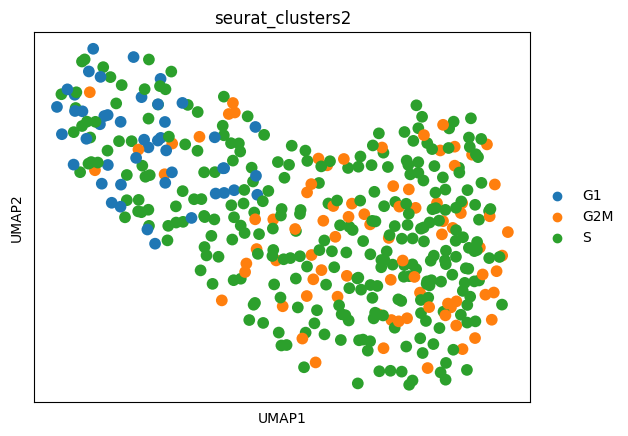

In [ ]:
# import scanpy as sc

# # 1. 数据预处理（如果尚未完成）
# # sc.pp.normalize_total(adata_sc1, target_sum=1e4)  # 总量归一化
# sc.pp.log1p(adata_sc1)                            # log变换
# # 使用更稳定的方式计算高变基因
# #sc.pp.highly_variable_genes(adata_sc1, n_top_genes=2000, flavor='seurat_v3')

# # 2. 高变基因筛选（可选，但常用）
# sc.pp.highly_variable_genes(adata_sc1, n_top_genes=2000)
# adata_sc1 = adata_sc1[:, adata_sc1.var.highly_variable]

# # 3. PCA 降维
# sc.pp.scale(adata_sc1, max_value=10)
# sc.tl.pca(adata_sc1, svd_solver='arpack')

# # 4. 构建邻接图
# sc.pp.neighbors(adata_sc1, n_neighbors=10, n_pcs=40)

# # 5. 计算 UMAP
# sc.tl.umap(adata_sc1)

# # 6. 可视化 UMAP（可选）
# sc.pl.umap(adata_sc1, color='seurat_clusters2')  # 用你关心的变量着色


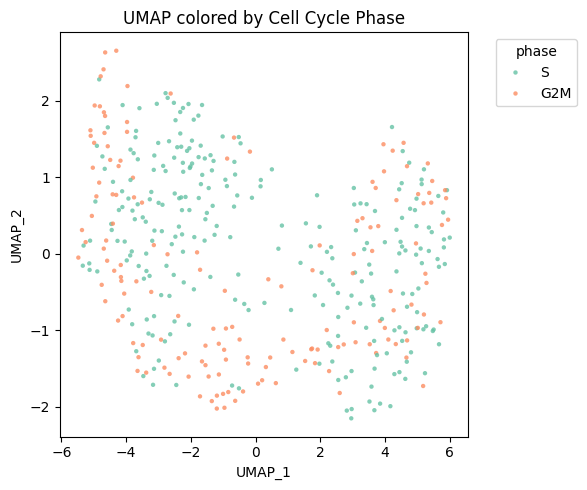

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 创建画布
plt.figure(figsize=(6, 5))

# 绘制 UMAP，按细胞周期着色
sns.scatterplot(
    x=adata_sc1.obs["UMAP_1"],
    y=adata_sc1.obs["UMAP_2"],
    hue=adata_sc1.obs["phase"],
    
    palette="Set2",    # 颜色可选 "tab10"、"Set1"、"Dark2" 等
    s=10,
    linewidth=0,
    alpha=0.8
)

# 添加标签
plt.xlabel("UMAP_1")
plt.ylabel("UMAP_2")
plt.title("UMAP colored by Cell Cycle Phase")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="phase")
plt.tight_layout()
plt.show()


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 定义颜色映射
custom_palette = {
    "S": "#64B9E8",
    "G1": "#57AA61",
    "G2M": "#CE57C0"
}

# 创建画布
plt.figure(figsize=(6, 5))

# 绘制 UMAP，按 phase 着色
sns.scatterplot(
    x=adata_sc1.obs["UMAP_1"],
    y=adata_sc1.obs["UMAP_2"],
    hue=adata_sc1.obs["phase"],
    palette=custom_palette,
    s=10,
    linewidth=0,
    alpha=0.8
)

# 添加标签和图例
plt.xlabel("UMAP_1")
plt.ylabel("UMAP_2")
plt.title("UMAP colored by Cell Cycle Phase")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Phase")
plt.tight_layout()

plt.savefig("ribofigure6d1umapproteinpri.pdf", format="pdf", bbox_inches='tight')

plt.show()


KeyError: 'UMAP_1'

<Figure size 600x500 with 0 Axes>

/tmp/ipykernel_2622209/4165548194.py:15: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=df_melted, x='phase', y='Score', hue='Score_Type',


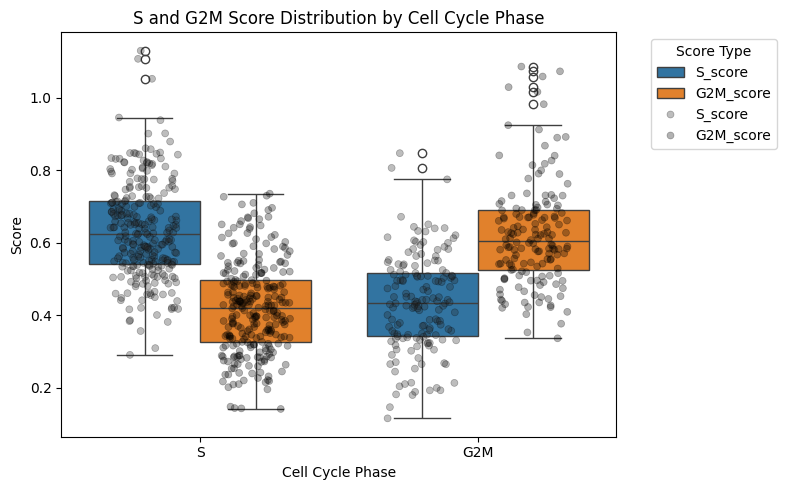

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 准备数据
df = adata_sc1.obs[['S_score', 'G2M_score', 'phase']].copy()

# 转换为长格式，适用于 seaborn 的 boxplot
df_melted = df.melt(id_vars='phase', value_vars=['S_score', 'G2M_score'],
                    var_name='Score_Type', value_name='Score')

# 绘图
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_melted, x='phase', y='Score', hue='Score_Type')
sns.stripplot(data=df_melted, x='phase', y='Score', hue='Score_Type',
              dodge=True, jitter=0.25, alpha=0.3, linewidth=0.5, color='black')

# 美化图例
plt.title("S and G2M Score Distribution by Cell Cycle Phase")
plt.xlabel("Cell Cycle Phase")
plt.ylabel("Score")
plt.legend(title="Score Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

# 提取数据
df = adata_sc1.obs[['S_score', 'G2M_score', 'phase']].copy()

# 分组计算每个 phase 中 S vs G2M 的 p 值
pval_results = []

for phase in df['phase'].unique():
    subset = df[df['phase'] == phase]
    try:
        stat, p = wilcoxon(subset['S_score'], subset['G2M_score'])
        pval_results.append({'phase': phase, 'p_value': p})
    except:
        pval_results.append({'phase': phase, 'p_value': None})  # 处理数据不够的问题

# 转换为 DataFrame 并添加显著性星号
pval_df = pd.DataFrame(pval_results)
pval_df['p_label'] = pval_df['p_value'].apply(
    lambda p: '***' if p is not None and p < 0.001 else
              '**' if p is not None and p < 0.01 else
              '*' if p is not None and p < 0.05 else
              'ns'
)

print(pval_df)


  phase       p_value p_label
0     S  3.242893e-45     ***
1   G2M  2.377567e-27     ***


In [49]:
# 根据 S_score 和 G2M_score 手动设置 phase
adata_sc1.obs['phase_manual'] = adata_sc1.obs.apply(
    lambda row: 'S' if row['S_score'] > row['G2M_score'] else 'G2M', axis=1
    
)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

# 提取数据
df = adata_sc1.obs[['S_score', 'G2M_score', 'phase_manual']].copy()

# 分组计算每个 phase 中 S vs G2M 的 p 值
pval_results = []

for phase in df['phase_manual'].unique():
    subset = df[df['phase_manual'] == phase]
    try:
        stat, p = wilcoxon(subset['S_score'], subset['G2M_score'])
        pval_results.append({'phase_manual': phase, 'p_value': p})
    except:
        pval_results.append({'phase_manual': phase, 'p_value': None})  # 处理数据不够的问题

# 转换为 DataFrame 并添加显著性星号
pval_df = pd.DataFrame(pval_results)
pval_df['p_label'] = pval_df['p_value'].apply(
    lambda p: '***' if p is not None and p < 0.001 else
              '**' if p is not None and p < 0.01 else
              '*' if p is not None and p < 0.05 else
              'ns'
)

print(pval_df)


  phase_manual       p_value p_label
0            S  3.242893e-45     ***
1          G2M  2.377567e-27     ***


/tmp/ipykernel_1817434/3105030657.py:18: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=df_melted, x='phase', y='Score', hue='Score_Type',


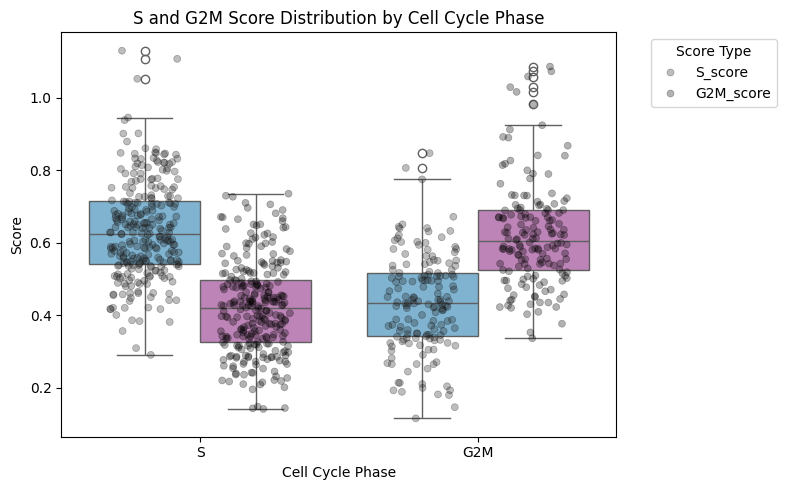

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 准备数据
df = adata_sc1.obs[['S_score', 'G2M_score', 'phase']].copy()

# 转换为长格式
df_melted = df.melt(id_vars='phase', value_vars=['S_score', 'G2M_score'],
                    var_name='Score_Type', value_name='Score')

# 自定义颜色
palette = {"S_score": "#72B7DD", "G2M_score": "#C67BBF"}

# 绘图
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_melted, x='phase', y='Score', hue='Score_Type', palette=palette)
sns.stripplot(data=df_melted, x='phase', y='Score', hue='Score_Type',
              dodge=True, jitter=0.25, alpha=0.3, linewidth=0.5, color='black')

# 移除重复图例
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))  # 去重
plt.legend(by_label.values(), by_label.keys(), title="Score Type", bbox_to_anchor=(1.05, 1), loc='upper left')

# 美化
plt.title("S and G2M Score Distribution by Cell Cycle Phase")
plt.xlabel("Cell Cycle Phase")
plt.ylabel("Score")
plt.tight_layout()

# 导出 PDF
plt.savefig("figure6pridicted_cell_cycle_scores.pdf")
plt.show()


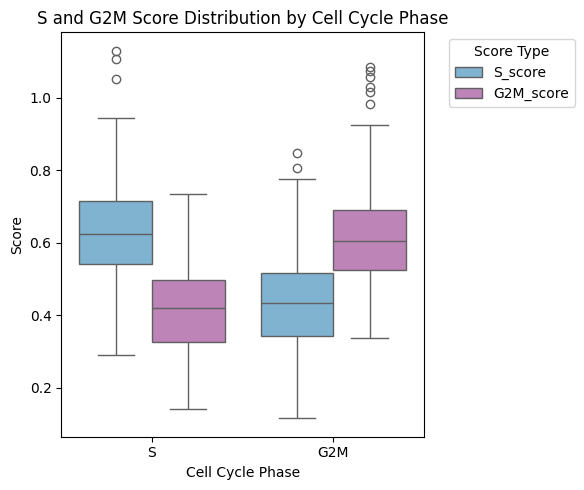

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 准备数据
df = adata_sc1.obs[['S_score', 'G2M_score', 'phase']].copy()

# 转换为长格式
df_melted = df.melt(id_vars='phase', value_vars=['S_score', 'G2M_score'],
                    var_name='Score_Type', value_name='Score')

# 自定义颜色
palette = {"S_score": "#72B7DD", "G2M_score": "#C67BBF"}

# 绘图
plt.figure(figsize=(6, 5))
sns.boxplot(data=df_melted, x='phase', y='Score', hue='Score_Type', palette=palette)

# 移除图例中的重复项
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))  # 去重
plt.legend(by_label.values(), by_label.keys(), title="Score Type", bbox_to_anchor=(1.05, 1), loc='upper left')

# 美化
plt.title("S and G2M Score Distribution by Cell Cycle Phase")
plt.xlabel("Cell Cycle Phase")
plt.ylabel("Score")
plt.tight_layout()

# 导出 PDF
plt.savefig("figure6pridicted_cell_cycle_scores2.pdf")
plt.show()


/tmp/ipykernel_2429553/2912710199.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=s_plot_df, x='Source', y='Score', palette=source_palette)


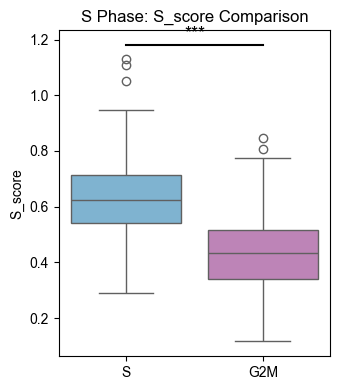

/tmp/ipykernel_2429553/2912710199.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=g2m_plot_df, x='Source', y='Score', palette=source_palette)


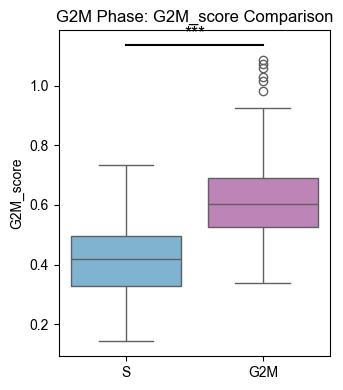

S_score p-value (S vs G2M): 7.3160e-39 (***)
G2M_score p-value (S vs G2M): 5.7851e-36 (***)


In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# 提取数据
df = adata_sc1.obs[['S_score', 'G2M_score', 'phase']].copy()

# 提取 S phase 和 G2M phase 的 S_score
s_df_s = df[df['phase'] == 'S'][['S_score']].copy()
s_df_g2m = df[df['phase'] == 'G2M'][['S_score']].copy()
s_df_s.rename(columns={'S_score': 'Score'}, inplace=True)
s_df_g2m.rename(columns={'S_score': 'Score'}, inplace=True)
s_df_s['Source'] = 'S'
s_df_g2m['Source'] = 'G2M'
s_plot_df = pd.concat([s_df_s, s_df_g2m])

# 提取 S phase 和 G2M phase 的 G2M_score
g2m_df_s = df[df['phase'] == 'S'][['G2M_score']].copy()
g2m_df_g2m = df[df['phase'] == 'G2M'][['G2M_score']].copy()
g2m_df_s.rename(columns={'G2M_score': 'Score'}, inplace=True)
g2m_df_g2m.rename(columns={'G2M_score': 'Score'}, inplace=True)
g2m_df_s['Source'] = 'S'
g2m_df_g2m['Source'] = 'G2M'
g2m_plot_df = pd.concat([g2m_df_s, g2m_df_g2m])

# 计算 p 值
s_p = ttest_ind(s_df_s['Score'], s_df_g2m['Score'], equal_var=False).pvalue
g2m_p = ttest_ind(g2m_df_s['Score'], g2m_df_g2m['Score'], equal_var=False).pvalue

# 显著性注释函数
def get_significance(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'

s_signif = get_significance(s_p)
g2m_signif = get_significance(g2m_p)

# 自定义颜色
source_palette = {
    'S': "#72B7DD",    # 蓝色
    'G2M': "#C67BBF"   # 紫红色
}

# 绘制 S_score 箱线图
plt.figure(figsize=(3.5, 4))
sns.boxplot(data=s_plot_df, x='Source', y='Score', palette=source_palette)
y_max = s_plot_df['Score'].max() + 0.05
plt.plot([0, 1], [y_max, y_max], color='black')
plt.text(0.5, y_max + 0.02, s_signif, ha='center', fontsize=13)
plt.title('S Phase: S_score Comparison')
plt.ylabel('S_score')
plt.xlabel('')
plt.tight_layout()
plt.show()

# 绘制 G2M_score 箱线图
plt.figure(figsize=(3.5, 4))
sns.boxplot(data=g2m_plot_df, x='Source', y='Score', palette=source_palette)
y_max = g2m_plot_df['Score'].max() + 0.05
plt.plot([0, 1], [y_max, y_max], color='black')
plt.text(0.5, y_max + 0.02, g2m_signif, ha='center', fontsize=13)
plt.title('G2M Phase: G2M_score Comparison')
plt.ylabel('G2M_score')
plt.xlabel('')
plt.tight_layout()
plt.show()

# 输出 p 值
print(f"S_score p-value (S vs G2M): {s_p:.4e} ({s_signif})")
print(f"G2M_score p-value (S vs G2M): {g2m_p:.4e} ({g2m_signif})")


In [7]:
import scanpy as sc
#原始数据分群
import pandas as pd
import numpy as np
# 读取数据，第一列为基因名，第一行为细胞名
df = pd.read_csv('/mnt/md0/luying/ribo/dnabert/DNABERT/examples/my_project/data/sc11619genes422cell_normalized.csv')

# 设置基因名为索引
df.set_index('Unnamed: 0', inplace=True)

# 构建 AnnData 对象（行为细胞，列为基因，需要转置）
adata_sc = sc.AnnData(df.T)

meta = pd.read_csv('/mnt/md0/luying/ribo/dnabert/DNABERT/examples/my_project/data/GSE162060_HEK293Tscriboseq_meta.csv')

adata_sc.obs['cell_type'] = meta['seurat_clusters'].values

adata_sc.obs['cell_type'] = adata_sc.obs['cell_type'].astype('category')
import scanpy as sc

# 1. 过滤掉极低表达的基因（可选）
sc.pp.filter_genes(adata_sc, min_cells=3)

# 2. 按每个细胞的总计数进行归一化（常用标准化方法）
#sc.pp.normalize_total(adata_sc, target_sum=1e4)

# 3. 对每个基因进行 log1p 转换（log(x + 1)）
sc.pp.log1p(adata_sc)


# 现在 adata_sc.X 中就是 log-normalized 的表达矩阵

import pandas as pd

# 读取包含坐标和cluster信息的CSV
clusters_df = pd.read_csv("data/umap_coordinates.csv", index_col=0)
clusters_df2 = pd.read_csv("data/proteinpridict_umap_clusters.csv", index_col=0)


# 确保索引（细胞名）对齐
common_cells = adata_sc.obs_names.intersection(clusters_df.index)

# 只保留两个对象中共有的细胞
adata_sc = adata_sc[common_cells].copy()
clusters_df = clusters_df.loc[common_cells]

# 将对应的坐标和cluster列赋值到 adata_sc.obs 中
adata_sc.obs["UMAP_1"] = clusters_df["UMAP_1"].values
adata_sc.obs["UMAP_2"] = clusters_df["UMAP_2"].values
adata_sc.obs["seurat_clusters"] = clusters_df2["seurat_clusters"].astype(str).values
adata_sc.obs["seurat_clusters2"] = clusters_df2["seurat_clusters2"].astype(str).values

import scanpy as sc

# 确保基因名是大写（和 Seurat 对应）
adata_sc.var_names = adata_sc.var_names.str.upper()

# 执行细胞周期评分
sc.tl.score_genes_cell_cycle(adata_sc, s_genes=s_genes, g2m_genes=g2m_genes)
# 结果保存在 obs 中：
print(adata_sc.obs[['S_score', 'G2M_score', 'phase']].head())

# phase 为预测的细胞周期阶段（'S', 'G2M', or 'G1'）




                            S_score  G2M_score phase
HEK293T-Starv1_AACCACGTCA  0.079510  -0.023788     S
HEK293T-Starv1_AACCGTAACA  0.024679  -0.039589     S
HEK293T-Starv1_AACCTAGACG  0.008051  -0.091393     S
HEK293T-Starv1_AACGCGGTAG  0.051478   0.060474   G2M
HEK293T-Starv1_AACTCTACCG  0.010500  -0.027660     S


In [8]:
# 提取 G1 期的细胞
g1_cells = adata_sc[adata_sc.obs['phase'] == 'G1', :].copy()
print(g1_cells.obs[['S_score', 'G2M_score', 'phase']].head())



                            S_score  G2M_score phase
HEK293T-Starv1_AATCTGTTGG -0.016618  -0.023322    G1
HEK293T-Starv1_ACAGAGACCG -0.029431  -0.013369    G1
HEK293T-Starv1_ACAGATCTCA -0.019316  -0.016789    G1
HEK293T-Starv1_ACGTATCTTG -0.077724  -0.102868    G1
HEK293T-Starv1_AGAACAATCG -0.031495  -0.031901    G1


In [9]:
# 根据 S_score 和 G2M_score 手动设置 phase
adata_sc.obs['phase_manual'] = adata_sc.obs.apply(
    lambda row: 'S' if row['S_score'] > row['G2M_score'] else 'G2M', axis=1
    
)


In [9]:
# 导出包含 index（细胞名）和 phase 的数据
phase_df = adata_sc.obs[['phase_manual']].copy()
phase_df.head()
# 保存为 CSV，index 设为列方便 R 使用
phase_df.to_csv("data/ribocell_cycle_phase.csv", index=True)


In [6]:
phase_df.head()

,phase
HEK293T-Starv1_AACCACGTCA,S
HEK293T-Starv1_AACCGTAACA,S
HEK293T-Starv1_AACCTAGACG,S
HEK293T-Starv1_AACGCGGTAG,G2M
HEK293T-Starv1_AACTCTACCG,S


In [ ]:
# # 确保基因名和变量匹配
# # 如果你做过大写转换，确保 gene list 也大写
# s_genes_upper = [g.upper() for g in s_genes]
# g2m_genes_upper = [g.upper() for g in g2m_genes]

# # 合并基因列表（去重）
# all_cycle_genes = list(set(s_genes_upper + g2m_genes_upper))

# # 目标细胞名称
# cell_id = "HEK293T-Starv1_AACCACGTCA"

# # 提取表达矩阵中这个细胞和这些基因的表达量
# expr_series = adata_sc[cell_id, all_cycle_genes].to_df().T  # 转置使基因为行

# # 打印结果
# print(expr_series)


/tmp/ipykernel_2459609/2604859805.py:15: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=df_melted, x='phase', y='Score', hue='Score_Type',


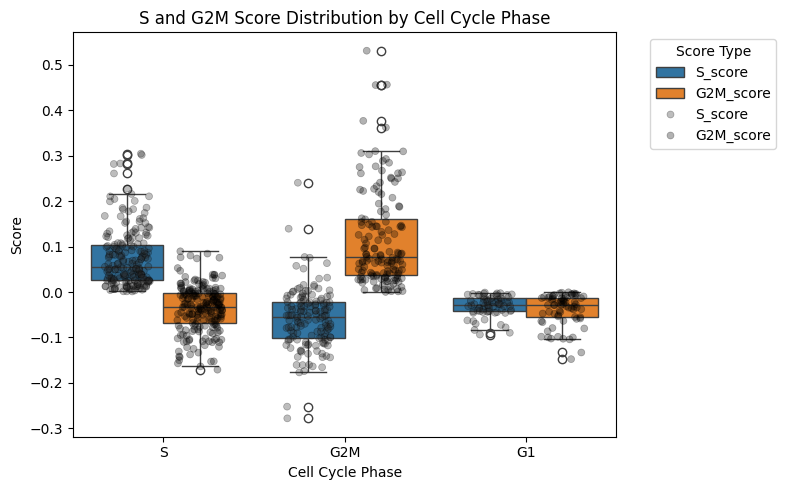

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 准备数据
df = adata_sc.obs[['S_score', 'G2M_score', 'phase']].copy()

# 转换为长格式，适用于 seaborn 的 boxplot
df_melted = df.melt(id_vars='phase', value_vars=['S_score', 'G2M_score'],
                    var_name='Score_Type', value_name='Score')

# 绘图
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_melted, x='phase', y='Score', hue='Score_Type')
sns.stripplot(data=df_melted, x='phase', y='Score', hue='Score_Type',
              dodge=True, jitter=0.25, alpha=0.3, linewidth=0.5, color='black')

# 美化图例
plt.title("S and G2M Score Distribution by Cell Cycle Phase")
plt.xlabel("Cell Cycle Phase")
plt.ylabel("Score")
plt.legend(title="Score Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()




In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

# 提取数据
df = adata_sc.obs[['S_score', 'G2M_score', 'phase']].copy()

# 分组计算每个 phase 中 S vs G2M 的 p 值
pval_results = []

for phase in df['phase'].unique():
    subset = df[df['phase'] == phase]
    try:
        stat, p = wilcoxon(subset['S_score'], subset['G2M_score'])
        pval_results.append({'phase': phase, 'p_value': p})
    except:
        pval_results.append({'phase': phase, 'p_value': None})  # 处理数据不够的问题

# 转换为 DataFrame 并添加显著性星号
pval_df = pd.DataFrame(pval_results)
pval_df['p_label'] = pval_df['p_value'].apply(
    lambda p: '***' if p is not None and p < 0.001 else
              '**' if p is not None and p < 0.01 else
              '*' if p is not None and p < 0.05 else
              'ns'
)

print(pval_df)


  phase       p_value p_label
0     S  3.173352e-35     ***
1   G2M  7.153812e-26     ***
2    G1  1.889085e-01      ns


In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

# 提取数据
df = adata_sc.obs[['S_score', 'G2M_score', 'phase_manual']].copy()

# 分组计算每个 phase 中 S vs G2M 的 p 值
pval_results = []

for phase in df['phase_manual'].unique():
    subset = df[df['phase_manual'] == phase]
    try:
        stat, p = wilcoxon(subset['S_score'], subset['G2M_score'])
        pval_results.append({'phase_manual': phase, 'p_value': p})
    except:
        pval_results.append({'phase_manual': phase, 'p_value': None})  # 处理数据不够的问题

# 转换为 DataFrame 并添加显著性星号
pval_df = pd.DataFrame(pval_results)
pval_df['p_label'] = pval_df['p_value'].apply(
    lambda p: '***' if p is not None and p < 0.001 else
              '**' if p is not None and p < 0.01 else
              '*' if p is not None and p < 0.05 else
              'ns'
)

print(pval_df)


  phase_manual       p_value p_label
0            S  6.095189e-42     ***
1          G2M  1.239317e-30     ***


phase 分组: ['S' 'G2M' 'G1']


/tmp/ipykernel_2429553/1202446145.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=s_plot_df, x='Source', y='Score', palette=source_palette)


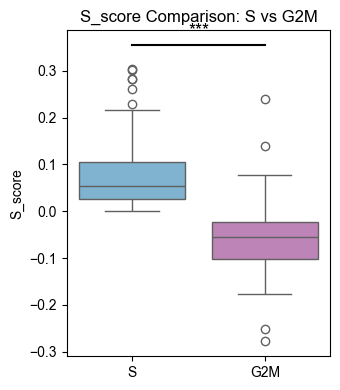

/tmp/ipykernel_2429553/1202446145.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=g2m_plot_df, x='Source', y='Score', palette=source_palette)


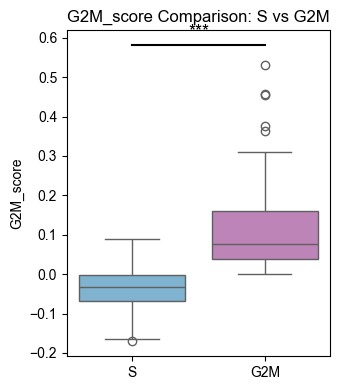

S_score: S vs G2M -> p-value = 3.2374e-54
G2M_score: S vs G2M -> p-value = 1.5567e-38


In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# 提取数据
df = adata_sc.obs[['S_score', 'G2M_score', 'phase']].copy()

# 检查 phase_manual 的唯一值，确保包含 "S" 和 "G2M"
print("phase 分组:", df['phase'].unique())

# 提取 S 和 G2M 的 S_score
s_df_s = df[df['phase'] == 'S'][['S_score']].copy()
s_df_g2m = df[df['phase'] == 'G2M'][['S_score']].copy()
s_df_s.rename(columns={'S_score': 'Score'}, inplace=True)
s_df_g2m.rename(columns={'S_score': 'Score'}, inplace=True)
s_df_s['Source'] = 'S'
s_df_g2m['Source'] = 'G2M'
s_plot_df = pd.concat([s_df_s, s_df_g2m])

# 提取 S 和 G2M 的 G2M_score
g2m_df_s = df[df['phase'] == 'S'][['G2M_score']].copy()
g2m_df_g2m = df[df['phase'] == 'G2M'][['G2M_score']].copy()
g2m_df_s.rename(columns={'G2M_score': 'Score'}, inplace=True)
g2m_df_g2m.rename(columns={'G2M_score': 'Score'}, inplace=True)
g2m_df_s['Source'] = 'S'
g2m_df_g2m['Source'] = 'G2M'
g2m_plot_df = pd.concat([g2m_df_s, g2m_df_g2m])

# 计算 p 值
s_p = ttest_ind(s_df_s['Score'], s_df_g2m['Score'], equal_var=False).pvalue
g2m_p = ttest_ind(g2m_df_s['Score'], g2m_df_g2m['Score'], equal_var=False).pvalue

# 显著性符号函数
def get_significance(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'

s_signif = get_significance(s_p)
g2m_signif = get_significance(g2m_p)

# 自定义颜色
source_palette = {
    'S': "#72B7DD",
    'G2M': "#C67BBF"
}

# 绘制 S_score 箱线图
plt.figure(figsize=(3.5, 4))
sns.boxplot(data=s_plot_df, x='Source', y='Score', palette=source_palette)
y_max = s_plot_df['Score'].max() + 0.05
plt.plot([0, 1], [y_max, y_max], color='black')
plt.text(0.5, y_max + 0.02, s_signif, ha='center', fontsize=13)
plt.title('S_score Comparison: S vs G2M')
plt.ylabel('S_score')
plt.xlabel('')
plt.tight_layout()
plt.show()

# 绘制 G2M_score 箱线图
plt.figure(figsize=(3.5, 4))
sns.boxplot(data=g2m_plot_df, x='Source', y='Score', palette=source_palette)
y_max = g2m_plot_df['Score'].max() + 0.05
plt.plot([0, 1], [y_max, y_max], color='black')
plt.text(0.5, y_max + 0.02, g2m_signif, ha='center', fontsize=13)
plt.title('G2M_score Comparison: S vs G2M')
plt.ylabel('G2M_score')
plt.xlabel('')
plt.tight_layout()
plt.show()

# 输出 p 值
print(f"S_score: S vs G2M -> p-value = {s_p:.4e}")
print(f"G2M_score: S vs G2M -> p-value = {g2m_p:.4e}")


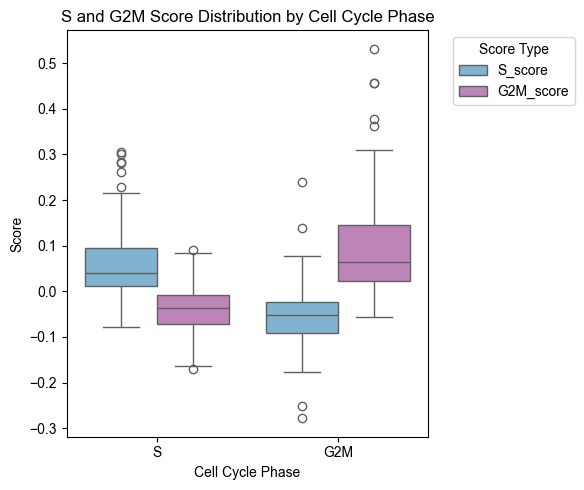

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams

# 设置字体为可编辑的矢量字体（如 Arial）
rcParams['pdf.fonttype'] = 42  # 使用 TrueType 字体
rcParams['ps.fonttype'] = 42
plt.rcParams['font.family'] = 'Arial'  # 可改为 'Times New Roman', 'Helvetica' 等

# 准备数据
df = adata_sc.obs[['S_score', 'G2M_score', 'phase_manual']].copy()

# 转换为长格式
df_melted = df.melt(id_vars='phase_manual', value_vars=['S_score', 'G2M_score'],
                    var_name='Score_Type', value_name='Score')

# 自定义颜色
palette = {"S_score": "#72B7DD", "G2M_score": "#C67BBF"}

# 绘图
plt.figure(figsize=(6, 5))
sns.boxplot(data=df_melted, x='phase_manual', y='Score', hue='Score_Type', palette=palette)

# 图例去重
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), title="Score Type", bbox_to_anchor=(1.05, 1), loc='upper left')

# 美化
plt.title("S and G2M Score Distribution by Cell Cycle Phase")
plt.xlabel("Cell Cycle Phase")
plt.ylabel("Score")
plt.tight_layout()

# 导出 PDF（字体可编辑）
plt.savefig("figure6ribo_cell_cycle_scores2.pdf")
plt.show()


phase_manual 分组: ['S' 'G2M']


/tmp/ipykernel_2429553/1228426368.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=s_plot_df, x='Source', y='Score', palette=source_palette)


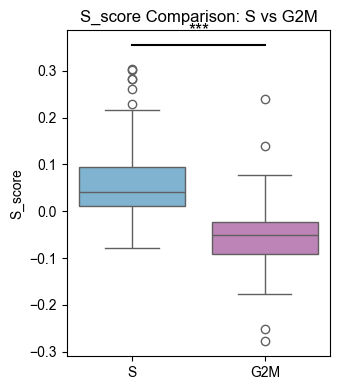

/tmp/ipykernel_2429553/1228426368.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=g2m_plot_df, x='Source', y='Score', palette=source_palette)


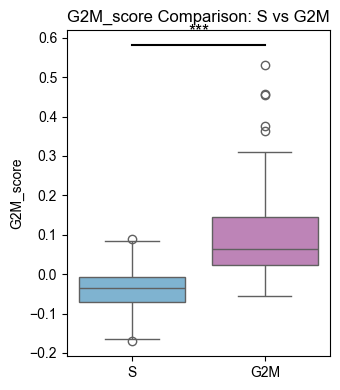

S_score: S vs G2M -> p-value = 1.3321e-53
G2M_score: S vs G2M -> p-value = 7.7756e-38


In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# 提取数据
df = adata_sc.obs[['S_score', 'G2M_score', 'phase_manual']].copy()

# 检查 phase_manual 的唯一值，确保包含 "S" 和 "G2M"
print("phase_manual 分组:", df['phase_manual'].unique())

# 提取 S 和 G2M 的 S_score
s_df_s = df[df['phase_manual'] == 'S'][['S_score']].copy()
s_df_g2m = df[df['phase_manual'] == 'G2M'][['S_score']].copy()
s_df_s.rename(columns={'S_score': 'Score'}, inplace=True)
s_df_g2m.rename(columns={'S_score': 'Score'}, inplace=True)
s_df_s['Source'] = 'S'
s_df_g2m['Source'] = 'G2M'
s_plot_df = pd.concat([s_df_s, s_df_g2m])

# 提取 S 和 G2M 的 G2M_score
g2m_df_s = df[df['phase_manual'] == 'S'][['G2M_score']].copy()
g2m_df_g2m = df[df['phase_manual'] == 'G2M'][['G2M_score']].copy()
g2m_df_s.rename(columns={'G2M_score': 'Score'}, inplace=True)
g2m_df_g2m.rename(columns={'G2M_score': 'Score'}, inplace=True)
g2m_df_s['Source'] = 'S'
g2m_df_g2m['Source'] = 'G2M'
g2m_plot_df = pd.concat([g2m_df_s, g2m_df_g2m])

# 计算 p 值
s_p = ttest_ind(s_df_s['Score'], s_df_g2m['Score'], equal_var=False).pvalue
g2m_p = ttest_ind(g2m_df_s['Score'], g2m_df_g2m['Score'], equal_var=False).pvalue

# 显著性符号函数
def get_significance(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'

s_signif = get_significance(s_p)
g2m_signif = get_significance(g2m_p)

# 自定义颜色
source_palette = {
    'S': "#72B7DD",
    'G2M': "#C67BBF"
}

# 绘制 S_score 箱线图
plt.figure(figsize=(3.5, 4))
sns.boxplot(data=s_plot_df, x='Source', y='Score', palette=source_palette)
y_max = s_plot_df['Score'].max() + 0.05
plt.plot([0, 1], [y_max, y_max], color='black')
plt.text(0.5, y_max + 0.02, s_signif, ha='center', fontsize=13)
plt.title('S_score Comparison: S vs G2M')
plt.ylabel('S_score')
plt.xlabel('')
plt.tight_layout()
plt.show()

# 绘制 G2M_score 箱线图
plt.figure(figsize=(3.5, 4))
sns.boxplot(data=g2m_plot_df, x='Source', y='Score', palette=source_palette)
y_max = g2m_plot_df['Score'].max() + 0.05
plt.plot([0, 1], [y_max, y_max], color='black')
plt.text(0.5, y_max + 0.02, g2m_signif, ha='center', fontsize=13)
plt.title('G2M_score Comparison: S vs G2M')
plt.ylabel('G2M_score')
plt.xlabel('')
plt.tight_layout()
plt.show()

# 输出 p 值
print(f"S_score: S vs G2M -> p-value = {s_p:.4e}")
print(f"G2M_score: S vs G2M -> p-value = {g2m_p:.4e}")


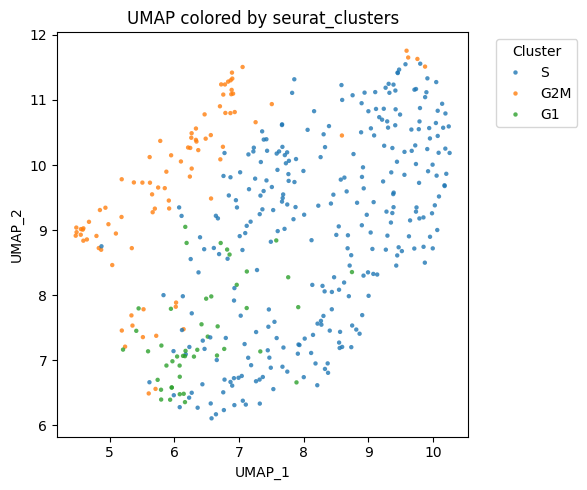

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 创建一个新图
plt.figure(figsize=(6, 5))

# 绘制散点图，用 seurat_clusters 上色
sns.scatterplot(
    x=adata_sc.obs["UMAP_1"],
    y=adata_sc.obs["UMAP_2"],
    hue=adata_sc.obs["seurat_clusters2"],
    palette="tab10",  # 可改为其他调色板，如 "Set2"、"Spectral"
    s=10,              # 点的大小
    linewidth=0,
    alpha=0.8
)


plt.title("UMAP colored by seurat_clusters")
plt.xlabel("UMAP_1")
plt.ylabel("UMAP_2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Cluster")
plt.tight_layout()
plt.show()



In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 创建画布
plt.figure(figsize=(6, 5))

# 绘制 UMAP，按细胞周期着色
sns.scatterplot(
    x=adata_sc.obs["UMAP_1"],
    y=adata_sc.obs["UMAP_2"],
    hue=adata_sc.obs["phase_manual"],
    
    palette="Set2",    # 颜色可选 "tab10"、"Set1"、"Dark2" 等
    s=10,
    linewidth=0,
    alpha=0.8
)

# 添加标签
plt.xlabel("UMAP_1")
plt.ylabel("UMAP_2")
plt.title("UMAP colored by Cell Cycle Phase")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="phase")
plt.tight_layout()
plt.show()


KeyError: 'phase_manual'

<Figure size 600x500 with 0 Axes>

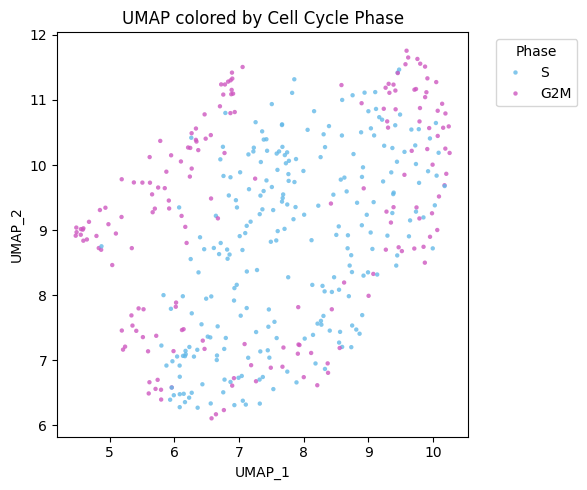

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

# 设置可编辑的矢量字体，例如 DejaVu Sans 或 Arial
matplotlib.rcParams['pdf.fonttype'] = 42  # 让文字在PDF中可编辑
matplotlib.rcParams['ps.fonttype'] = 42
plt.rcParams['font.family'] = 'DejaVu Sans'  # 或 'Arial'，需系统已安装

# 定义颜色映射
custom_palette = {
    "S": "#64B9E8",
    "G1": "#57AA61",
    "G2M": "#CE57C0"
}

# 创建画布
plt.figure(figsize=(6, 5))

# 绘制 UMAP，按 phase 着色
sns.scatterplot(
    x=adata_sc.obs["UMAP_1"],
    y=adata_sc.obs["UMAP_2"],
    hue=adata_sc.obs["phase_manual"],
    palette=custom_palette,
    s=10,
    linewidth=0,
    alpha=0.8
)

# 添加标签和图例
plt.xlabel("UMAP_1")
plt.ylabel("UMAP_2")
plt.title("UMAP colored by Cell Cycle Phase")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Phase")
plt.tight_layout()

# 保存为 PDF 文件，文字可编辑
plt.savefig("ribofigure6d1umapribo22.pdf", format="pdf", bbox_inches='tight')

plt.show()


In [ ]:
# 读取数据，第一列为基因名，第一行为细胞名
df = pd.read_csv('/mnt/md0/luying/ribo/308code/pausing/data/sc11619genes422cell_normalized.csv')
df.head

<bound method NDFrame.head of             Unnamed: 0  HEK293T-Starv1_AACCACGTCA  HEK293T-Starv1_AACCGTAACA  \
0      ENST00000000233                   0.233792                   0.467583   
1      ENST00000000412                   0.865455                   0.000000   
2      ENST00000001008                   0.138453                   0.069226   
3      ENST00000002125                   0.000000                   0.000000   
4      ENST00000002165                   0.413194                   0.413194   
...                ...                        ...                        ...   
11614  ENST00000674115                   0.000000                   0.000000   
11615  ENST00000674165                   0.000000                   0.000000   
11616  ENST00000674273                   0.000000                   0.000000   
11617  ENST00000674289                   0.000000                   0.000000   
11618  ENST00000674316                   0.000000                   0.000000   

       HE

In [ ]:
# 读取数据，第一列为基因名，第一行为细胞名
df = pd.read_csv('/mnt/md0/luying/ribo/308code/pausing/data/sc11619genes422cell_normalized.csv')
df.head

In [ ]:
import scanpy as sc
#原始数据分群
import pandas as pd
import numpy as np
# 读取数据，第一列为基因名，第一行为细胞名
df = pd.read_csv('/mnt/md0/luying/ribo/dnabert/DNABERT/examples/my_project/data/sc11619genes422cell_normalized.csv')

# 设置基因名为索引
df.set_index('Unnamed: 0', inplace=True)

# 构建 AnnData 对象（行为细胞，列为基因，需要转置）
adata_sc = sc.AnnData(df.T)

meta = pd.read_csv('/mnt/md0/luying/ribo/dnabert/DNABERT/examples/my_project/data/GSE162060_HEK293Tscriboseq_meta.csv')

adata_sc.obs['cell_type'] = meta['seurat_clusters'].values

adata_sc.obs['cell_type'] = adata_sc.obs['cell_type'].astype('category')
import scanpy as sc

# 1. 过滤掉极低表达的基因（可选）
sc.pp.filter_genes(adata_sc, min_cells=3)

# 2. 按每个细胞的总计数进行归一化（常用标准化方法）
#sc.pp.normalize_total(adata_sc, target_sum=1e4)

# 3. 对每个基因进行 log1p 转换（log(x + 1)）
sc.pp.log1p(adata_sc)


# 现在 adata_sc.X 中就是 log-normalized 的表达矩阵

import pandas as pd

# 读取包含坐标和cluster信息的CSV
clusters_df = pd.read_csv("data/proteinpridict_umap_clusters.csv", index_col=0)


# 确保索引（细胞名）对齐
common_cells = adata_sc.obs_names.intersection(clusters_df.index)

# 只保留两个对象中共有的细胞
adata_sc = adata_sc[common_cells].copy()
clusters_df = clusters_df.loc[common_cells]

# 将对应的坐标和cluster列赋值到 adata_sc.obs 中
adata_sc.obs["UMAP_1"] = clusters_df["UMAP_1"].values
adata_sc.obs["UMAP_2"] = clusters_df["UMAP_2"].values
adata_sc.obs["seurat_clusters"] = clusters_df["seurat_clusters"].astype(str).values
adata_sc.obs["seurat_clusters2"] = clusters_df["seurat_clusters2"].astype(str).values

import scanpy as sc

# 确保基因名是大写（和 Seurat 对应）
adata_sc.var_names = adata_sc.var_names.str.upper()

# 执行细胞周期评分
sc.tl.score_genes_cell_cycle(adata_sc, s_genes=s_genes, g2m_genes=g2m_genes)
# 结果保存在 obs 中：
print(adata_sc.obs[['S_score', 'G2M_score', 'phase']].head())

# phase 为预测的细胞周期阶段（'S', 'G2M', or 'G1'）




                            S_score  G2M_score phase
HEK293T-Starv1_AACCACGTCA  0.079510  -0.023788     S
HEK293T-Starv1_AACCGTAACA  0.024679  -0.039589     S
HEK293T-Starv1_AACCTAGACG  0.008051  -0.091393     S
HEK293T-Starv1_AACGCGGTAG  0.051478   0.060474   G2M
HEK293T-Starv1_AACTCTACCG  0.010500  -0.027660     S


                 HEK293T-Starv1_AACCACGTCA
Unnamed: 0                                
ENST00000314103                   0.173272
ENST00000230056                   0.208797
ENST00000242576                   0.313658
ENST00000209875                   0.116399
ENST00000454366                   0.000000
...                                    ...
ENST00000260363                   0.197496
ENST00000366548                   0.463786
ENST00000338179                   0.000000
ENST00000411486                   0.351005
ENST00000308987                   0.000000

[89 rows x 1 columns]


/tmp/ipykernel_1667553/3145128460.py:31: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=df_melted, x='phase', y='Score', hue='Score_Type',


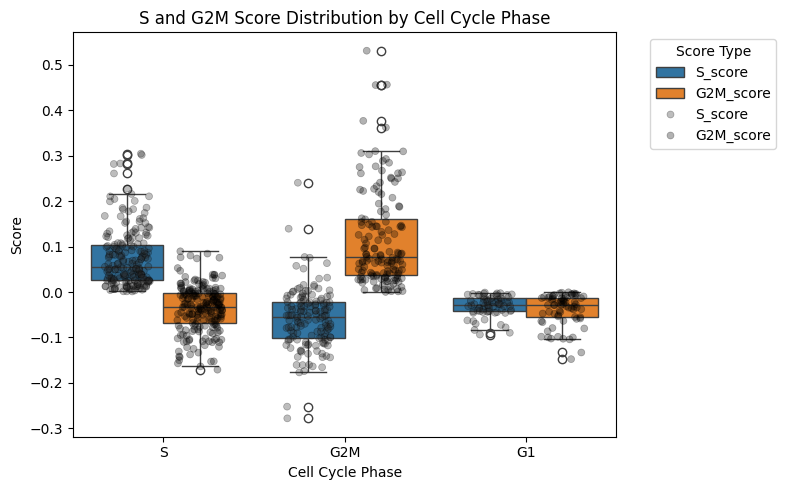

In [ ]:
# 确保基因名和变量匹配
# 如果你做过大写转换，确保 gene list 也大写
s_genes_upper = [g.upper() for g in s_genes]
g2m_genes_upper = [g.upper() for g in g2m_genes]

# 合并基因列表（去重）
all_cycle_genes = list(set(s_genes_upper + g2m_genes_upper))

# 目标细胞名称
cell_id = "HEK293T-Starv1_AACCACGTCA"

# 提取表达矩阵中这个细胞和这些基因的表达量
expr_series = adata_sc[cell_id, all_cycle_genes].to_df().T  # 转置使基因为行

# 打印结果
print(expr_series)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 准备数据
df = adata_sc.obs[['S_score', 'G2M_score', 'phase']].copy()

# 转换为长格式，适用于 seaborn 的 boxplot
df_melted = df.melt(id_vars='phase', value_vars=['S_score', 'G2M_score'],
                    var_name='Score_Type', value_name='Score')

# 绘图
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_melted, x='phase', y='Score', hue='Score_Type')
sns.stripplot(data=df_melted, x='phase', y='Score', hue='Score_Type',
              dodge=True, jitter=0.25, alpha=0.3, linewidth=0.5, color='black')

# 美化图例
plt.title("S and G2M Score Distribution by Cell Cycle Phase")
plt.xlabel("Cell Cycle Phase")
plt.ylabel("Score")
plt.legend(title="Score Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()




S_phase S_score p-value: 7.1777e-201
G2M_phase G2M_score p-value: 3.3905e-105


/tmp/ipykernel_1667553/3606500610.py:37: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=plot_df, x='Phase', y='Score', hue='Source',


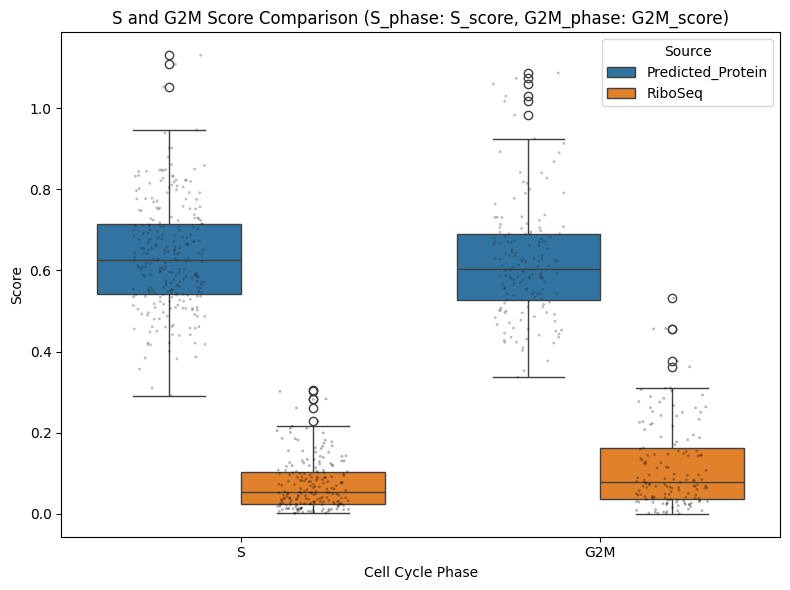

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# 提取 phase 为 S 的细胞的 S_score
s_df1 = adata_sc1.obs[adata_sc1.obs['phase'] == 'S'][['S_score']].copy()
s_df1['Phase'] = 'S'
s_df1['Source'] = 'Predicted_Protein'

s_df2 = adata_sc.obs[adata_sc.obs['phase'] == 'S'][['S_score']].copy()
s_df2['Phase'] = 'S'
s_df2['Source'] = 'RiboSeq'

# 提取 phase 为 G2M 的细胞的 G2M_score
g2m_df1 = adata_sc1.obs[adata_sc1.obs['phase'] == 'G2M'][['G2M_score']].copy()
g2m_df1.rename(columns={'G2M_score': 'Score'}, inplace=True)
g2m_df1['Phase'] = 'G2M'
g2m_df1['Source'] = 'Predicted_Protein'

g2m_df2 = adata_sc.obs[adata_sc.obs['phase'] == 'G2M'][['G2M_score']].copy()
g2m_df2.rename(columns={'G2M_score': 'Score'}, inplace=True)
g2m_df2['Phase'] = 'G2M'
g2m_df2['Source'] = 'RiboSeq'

# 对 S_score 的列重命名
s_df1.rename(columns={'S_score': 'Score'}, inplace=True)
s_df2.rename(columns={'S_score': 'Score'}, inplace=True)

# 合并所有数据
plot_df = pd.concat([s_df1, s_df2, g2m_df1, g2m_df2])

# 绘图
plt.figure(figsize=(8, 6))
sns.boxplot(data=plot_df, x='Phase', y='Score', hue='Source',
            palette={'Predicted_Protein': '#1f77b4', 'RiboSeq': '#ff7f0e'})
sns.stripplot(data=plot_df, x='Phase', y='Score', hue='Source',
              dodge=True, color='black', alpha=0.3, jitter=0.2, size=2)

# 移除重复图例
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], title='Source')

plt.title('S and G2M Score Comparison (S_phase: S_score, G2M_phase: G2M_score)')
plt.xlabel('Cell Cycle Phase')
plt.ylabel('Score')
plt.tight_layout()

# 计算 p 值
s_score_p = ttest_ind(
    s_df1['Score'].dropna(), s_df2['Score'].dropna(), equal_var=False
).pvalue
g2m_score_p = ttest_ind(
    g2m_df1['Score'].dropna(), g2m_df2['Score'].dropna(), equal_var=False
).pvalue

print(f"S_phase S_score p-value: {s_score_p:.4e}")
print(f"G2M_phase G2M_score p-value: {g2m_score_p:.4e}")

plt.show()


/tmp/ipykernel_1639159/547344763.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=s_plot_df, x='Source', y='Score', palette=source_palette)


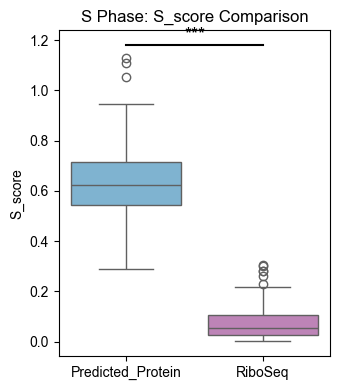

/tmp/ipykernel_1639159/547344763.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=g2m_plot_df, x='Source', y='Score', palette=source_palette)


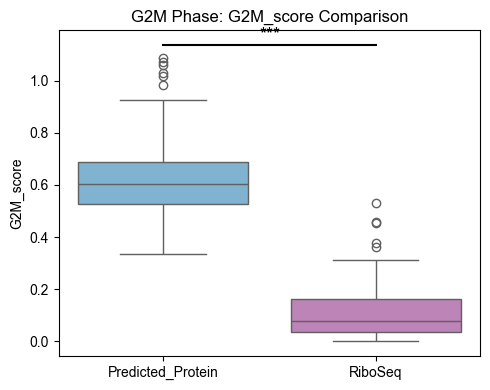

S_phase S_score p-value: 7.1777e-201
G2M_phase G2M_score p-value: 3.3905e-105


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# 提取数据（略去重复，保留和你一样的逻辑）
s_df1 = adata_sc1.obs[adata_sc1.obs['phase'] == 'S'][['S_score']].copy()
s_df2 = adata_sc.obs[adata_sc.obs['phase'] == 'S'][['S_score']].copy()
s_df1['Source'] = 'Predicted_Protein'
s_df2['Source'] = 'RiboSeq'
s_df1.rename(columns={'S_score': 'Score'}, inplace=True)
s_df2.rename(columns={'S_score': 'Score'}, inplace=True)
s_plot_df = pd.concat([s_df1, s_df2])

g2m_df1 = adata_sc1.obs[adata_sc1.obs['phase'] == 'G2M'][['G2M_score']].copy()
g2m_df2 = adata_sc.obs[adata_sc.obs['phase'] == 'G2M'][['G2M_score']].copy()
g2m_df1['Source'] = 'Predicted_Protein'
g2m_df2['Source'] = 'RiboSeq'
g2m_df1.rename(columns={'G2M_score': 'Score'}, inplace=True)
g2m_df2.rename(columns={'G2M_score': 'Score'}, inplace=True)
g2m_plot_df = pd.concat([g2m_df1, g2m_df2])

# 计算 p 值和显著性符号
def get_significance(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'

s_p = ttest_ind(s_df1['Score'], s_df2['Score'], equal_var=False).pvalue
g2m_p = ttest_ind(g2m_df1['Score'], g2m_df2['Score'], equal_var=False).pvalue
s_signif = get_significance(s_p)
g2m_signif = get_significance(g2m_p)

# 自定义颜色
source_palette = {
    'Predicted_Protein': "#72B7DD",  # 蓝色
    'RiboSeq': "#C67BBF"            # 紫红色
}

# 绘制 S_phase 箱线图
plt.figure(figsize=(3.5, 4))
sns.boxplot(data=s_plot_df, x='Source', y='Score', palette=source_palette)
y_max = s_plot_df['Score'].max() + 0.05
plt.plot([0, 1], [y_max, y_max], color='black')
plt.text(0.5, y_max + 0.02, s_signif, ha='center', fontsize=13)
plt.title('S Phase: S_score Comparison')
plt.ylabel('S_score')
plt.xlabel('')
plt.tight_layout()
plt.show()

# 绘制 G2M_phase 箱线图
plt.figure(figsize=(5, 4))
sns.boxplot(data=g2m_plot_df, x='Source', y='Score', palette=source_palette)
y_max = g2m_plot_df['Score'].max() + 0.05
plt.plot([0, 1], [y_max, y_max], color='black')
plt.text(0.5, y_max + 0.02, g2m_signif, ha='center', fontsize=13)
plt.title('G2M Phase: G2M_score Comparison')
plt.ylabel('G2M_score')
plt.xlabel('')
plt.tight_layout()
plt.show()

# 输出 p 值
print(f"S_phase S_score p-value: {s_p:.4e}")
print(f"G2M_phase G2M_score p-value: {g2m_p:.4e}")


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from matplotlib import rcParams, rc

# 设置字体嵌入为可编辑
rcParams['pdf.fonttype'] = 42  # TrueType
rcParams['ps.fonttype'] = 42
rc('font', family='Arial')     # 使用可编辑字体，如 Arial / Helvetica

# 提取数据（逻辑相同）
s_df1 = adata_sc1.obs[adata_sc1.obs['phase'] == 'S'][['S_score']].copy()
s_df2 = adata_sc.obs[adata_sc.obs['phase'] == 'S'][['S_score']].copy()
s_df1['Source'] = 'Predicted_Protein'
s_df2['Source'] = 'RiboSeq'
s_df1.rename(columns={'S_score': 'Score'}, inplace=True)
s_df2.rename(columns={'S_score': 'Score'}, inplace=True)
s_plot_df = pd.concat([s_df1, s_df2])

g2m_df1 = adata_sc1.obs[adata_sc1.obs['phase'] == 'G2M'][['G2M_score']].copy()
g2m_df2 = adata_sc.obs[adata_sc.obs['phase'] == 'G2M'][['G2M_score']].copy()
g2m_df1['Source'] = 'Predicted_Protein'
g2m_df2['Source'] = 'RiboSeq'
g2m_df1.rename(columns={'G2M_score': 'Score'}, inplace=True)
g2m_df2.rename(columns={'G2M_score': 'Score'}, inplace=True)
g2m_plot_df = pd.concat([g2m_df1, g2m_df2])

# 计算 p 值和显著性
def get_significance(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'

s_p = ttest_ind(s_df1['Score'], s_df2['Score'], equal_var=False).pvalue
g2m_p = ttest_ind(g2m_df1['Score'], g2m_df2['Score'], equal_var=False).pvalue
s_signif = get_significance(s_p)
g2m_signif = get_significance(g2m_p)

# 自定义颜色
source_palette = {
    'Predicted_Protein': "#72B7DD",
    'RiboSeq': "#C67BBF"
}

# S phase 图
plt.figure(figsize=(3.5, 4))
sns.boxplot(data=s_plot_df, x='Source', y='Score', palette=source_palette)
y_max = s_plot_df['Score'].max() + 0.05
plt.plot([0, 1], [y_max, y_max], color='black')
plt.text(0.5, y_max + 0.02, s_signif, ha='center', fontsize=13)
plt.title('S Phase: S_score Comparison')
plt.ylabel('S_score')
plt.xlabel('')
plt.tight_layout()
plt.savefig("ribofigure6S_phase_score_comparison.pdf", format="pdf")  # 保存 PDF
plt.close()

# G2M phase 图
plt.figure(figsize=(3.5, 4))
sns.boxplot(data=g2m_plot_df, x='Source', y='Score', palette=source_palette)
y_max = g2m_plot_df['Score'].max() + 0.05
plt.plot([0, 1], [y_max, y_max], color='black')
plt.text(0.5, y_max + 0.02, g2m_signif, ha='center', fontsize=13)
plt.title('G2M Phase: G2M_score Comparison')
plt.ylabel('G2M_score')
plt.xlabel('')
plt.tight_layout()
plt.savefig("ribofigure6G2M_phase_score_comparison.pdf", format="pdf")  # 保存 PDF
plt.close()

# 输出 p 值
print(f"S_phase S_score p-value: {s_p:.4e}")
print(f"G2M_phase G2M_score p-value: {g2m_p:.4e}")


S_phase S_score p-value: 7.1777e-201
G2M_phase G2M_score p-value: 3.3905e-105


/tmp/ipykernel_1667553/687347960.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=s_plot_df, x='Source', y='Score', palette=source_palette)
/tmp/ipykernel_1667553/687347960.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=g2m_plot_df, x='Source', y='Score', palette=source_palette)


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from scipy.stats import ttest_ind

# 设置 PDF 输出字体为可编辑
plt.rcParams['pdf.fonttype'] = 42  # TrueType 字体
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.family'] = 'Arial'  # 可替换为 Helvetica 等你系统中已有的字体

# 数据处理（同前）
s_df1 = adata_sc1.obs[adata_sc1.obs['phase'] == 'S'][['S_score']].copy()
s_df2 = adata_sc.obs[adata_sc.obs['phase'] == 'S'][['S_score']].copy()
s_df1['Source'] = 'Predicted_Protein'
s_df2['Source'] = 'RiboSeq'
s_df1.rename(columns={'S_score': 'Score'}, inplace=True)
s_df2.rename(columns={'S_score': 'Score'}, inplace=True)
s_plot_df = pd.concat([s_df1, s_df2])

g2m_df1 = adata_sc1.obs[adata_sc1.obs['phase'] == 'G2M'][['G2M_score']].copy()
g2m_df2 = adata_sc.obs[adata_sc.obs['phase'] == 'G2M'][['G2M_score']].copy()
g2m_df1['Source'] = 'Predicted_Protein'
g2m_df2['Source'] = 'RiboSeq'
g2m_df1.rename(columns={'G2M_score': 'Score'}, inplace=True)
g2m_df2.rename(columns={'G2M_score': 'Score'}, inplace=True)
g2m_plot_df = pd.concat([g2m_df1, g2m_df2])

# 计算显著性
def get_significance(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'

s_p = ttest_ind(s_df1['Score'], s_df2['Score'], equal_var=False).pvalue
g2m_p = ttest_ind(g2m_df1['Score'], g2m_df2['Score'], equal_var=False).pvalue
s_signif = get_significance(s_p)
g2m_signif = get_significance(g2m_p)

# 自定义颜色
source_palette = {
    'Predicted_Protein': "#72B7DD",  # 蓝色
    'RiboSeq': "#C67BBF"            # 紫红色
}

# 保存为 PDF
with PdfPages("data/ribofigure6cell_cycle_score_comparison.pdf") as pdf:
    # S Phase
    plt.figure(figsize=(3.5, 4))
    sns.boxplot(data=s_plot_df, x='Source', y='Score', palette=source_palette)
    y_max = s_plot_df['Score'].max() + 0.05
    plt.plot([0, 1], [y_max, y_max], color='black')
    plt.text(0.5, y_max + 0.02, s_signif, ha='center', fontsize=13)
    plt.title('S Phase: S_score Comparison')
    plt.ylabel('S_score')
    plt.xlabel('')
    plt.tight_layout()
    pdf.savefig()  # 保存当前页
    plt.close()

    # G2M Phase
    plt.figure(figsize=(3.5, 4))
    sns.boxplot(data=g2m_plot_df, x='Source', y='Score', palette=source_palette)
    y_max = g2m_plot_df['Score'].max() + 0.05
    plt.plot([0, 1], [y_max, y_max], color='black')
    plt.text(0.5, y_max + 0.02, g2m_signif, ha='center', fontsize=13)
    plt.title('G2M Phase: G2M_score Comparison')
    plt.ylabel('G2M_score')
    plt.xlabel('')
    plt.tight_layout()
    pdf.savefig()
    plt.close()

# 输出 p 值
print(f"S_phase S_score p-value: {s_p:.4e}")
print(f"G2M_phase G2M_score p-value: {g2m_p:.4e}")


/tmp/ipykernel_1639159/3291782379.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=s_df, x='Source', y='Expression',


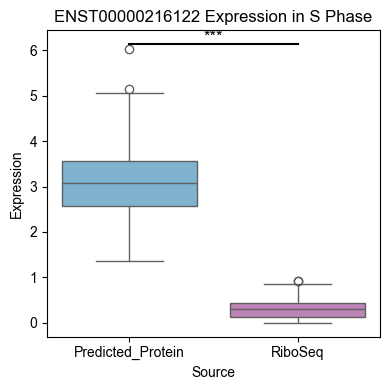

In [ ]:
gene_id = "ENST00000216122"
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# 提取 S 期的表达数据
s_expr1 = adata_sc1[adata_sc1.obs['phase'] == 'S'][:, gene_id].X.toarray().flatten()
s_expr2 = adata_sc[adata_sc.obs['phase'] == 'S'][:, gene_id].X.toarray().flatten()

# 构建 DataFrame
s_df = pd.DataFrame({
    'Expression': list(s_expr1) + list(s_expr2),
    'Source': ['Predicted_Protein'] * len(s_expr1) + ['RiboSeq'] * len(s_expr2)
})

# 计算 p 值
s_p = ttest_ind(s_expr1, s_expr2, equal_var=False).pvalue
s_signif = '***' if s_p < 0.001 else '**' if s_p < 0.01 else '*' if s_p < 0.05 else 'ns'

# 绘图
plt.figure(figsize=(4, 4))
sns.boxplot(data=s_df, x='Source', y='Expression',
            palette={'Predicted_Protein': "#72B7DD", 'RiboSeq': "#C67BBF"})
plt.title(f"{gene_id} Expression in S Phase")
ymax = s_df['Expression'].max() + 0.1
plt.plot([0, 1], [ymax, ymax], color='black')
plt.text(0.5, ymax + 0.05, s_signif, ha='center', fontsize=12)
plt.tight_layout()
plt.show()


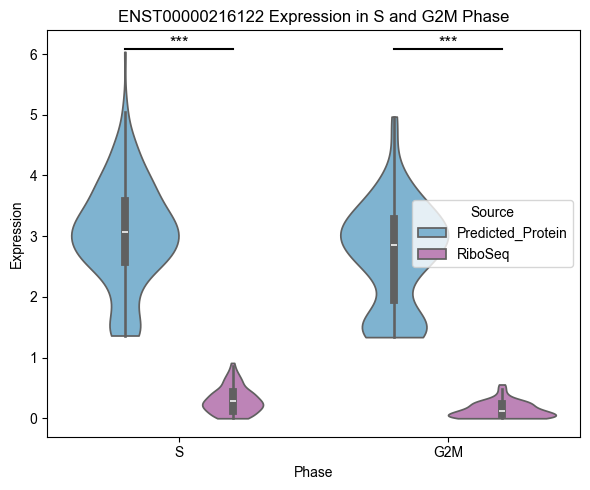

S phase p-value: 1.9281e-152
G2M phase p-value: 1.3864e-81


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# 指定基因 ID
gene_id = "ENST00000216122"

# 提取表达数据并构造 DataFrame
def extract_expr(adata, phase, label):
    expr = adata[adata.obs['phase'] == phase][:, gene_id].X.toarray().flatten()
    return pd.DataFrame({
        "Expression": expr,
        "Phase": phase,
        "Source": label
    })

# 构建所有数据
s_df1 = extract_expr(adata_sc1, "S", "Predicted_Protein")
s_df2 = extract_expr(adata_sc, "S", "RiboSeq")
g_df1 = extract_expr(adata_sc1, "G2M", "Predicted_Protein")
g_df2 = extract_expr(adata_sc, "G2M", "RiboSeq")

plot_df = pd.concat([s_df1, s_df2, g_df1, g_df2])

# 生成 p 值和显著性注释
def get_significance(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'

s_p = ttest_ind(s_df1['Expression'], s_df2['Expression'], equal_var=False).pvalue
g_p = ttest_ind(g_df1['Expression'], g_df2['Expression'], equal_var=False).pvalue
s_signif = get_significance(s_p)
g_signif = get_significance(g_p)

# 小提琴图绘图
plt.figure(figsize=(6, 5))
sns.violinplot(data=plot_df, x="Phase", y="Expression", hue="Source",
               palette={"Predicted_Protein": "#72B7DD", "RiboSeq": "#C67BBF"},
               cut=0, inner="box")

# 添加 p 值注释
y_max = plot_df["Expression"].max()
plt.plot([-0.2, 0.2], [y_max + 0.05, y_max + 0.05], color="black")
plt.text(0, y_max + 0.07, s_signif, ha="center", fontsize=12)

plt.plot([0.8, 1.2], [y_max + 0.05, y_max + 0.05], color="black")
plt.text(1, y_max + 0.07, g_signif, ha="center", fontsize=12)

# 美化图像
plt.title(f"{gene_id} Expression in S and G2M Phase")
plt.xlabel("Phase")
plt.ylabel("Expression")
plt.legend(title="Source")
plt.tight_layout()
plt.show()

# 输出 p 值
print(f"S phase p-value: {s_p:.4e}")
print(f"G2M phase p-value: {g_p:.4e}")


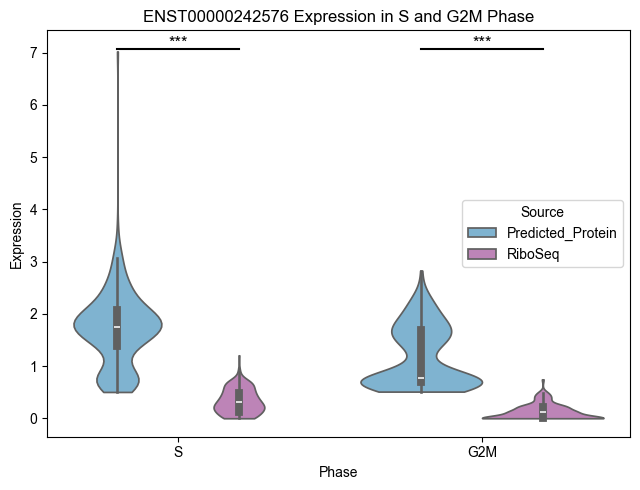

Predicted Protein S vs G2M p-value: 1.6844e-15
RiboSeq S vs G2M p-value: 1.1099e-22


In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# 指定基因 ID
gene_id = "ENST00000242576"

# 提取表达数据函数
def extract_expr(adata, phase, source_label):
    expr = adata[adata.obs['phase'] == phase][:, gene_id].X.toarray().flatten()
    return pd.DataFrame({
        "Expression": expr,
        "Phase": phase,
        "Source": source_label
    })

# 构造数据
adata_sc1_s = extract_expr(adata_sc1, "S", "Predicted_Protein")
adata_sc1_g = extract_expr(adata_sc1, "G2M", "Predicted_Protein")
adata_sc_s = extract_expr(adata_sc, "S", "RiboSeq")
adata_sc_g = extract_expr(adata_sc, "G2M", "RiboSeq")

# 合并成一个 DataFrame
plot_df = pd.concat([adata_sc1_s, adata_sc1_g, adata_sc_s, adata_sc_g])

# 分别计算 p 值
def get_significance(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'

p_pred = ttest_ind(adata_sc1_s['Expression'], adata_sc1_g['Expression'], equal_var=False).pvalue
p_ribo = ttest_ind(adata_sc_s['Expression'], adata_sc_g['Expression'], equal_var=False).pvalue
signif_pred = get_significance(p_pred)
signif_ribo = get_significance(p_ribo)

# 画图
plt.figure(figsize=(6.5, 5))
sns.violinplot(data=plot_df, x="Phase", y="Expression", hue="Source",
               palette={"Predicted_Protein": "#72B7DD", "RiboSeq": "#C67BBF"},
               cut=0, inner="box")

# 添加 p 值标注
ymax = plot_df['Expression'].max()
plt.plot([-0.2, 0.2], [ymax + 0.05, ymax + 0.05], color='black')
plt.text(0, ymax + 0.07, signif_pred, ha='center', fontsize=12)

plt.plot([0.8, 1.2], [ymax + 0.05, ymax + 0.05], color='black')
plt.text(1, ymax + 0.07, signif_ribo, ha='center', fontsize=12)

# 美化
plt.title(f"{gene_id} Expression in S and G2M Phase")
plt.xlabel("Phase")
plt.ylabel("Expression")
plt.legend(title="Source")
plt.tight_layout()
plt.show()

# 输出 p 值
print(f"Predicted Protein S vs G2M p-value: {p_pred:.4e}")
print(f"RiboSeq S vs G2M p-value: {p_ribo:.4e}")


/tmp/ipykernel_3069314/3544914763.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="Group", y="Expression", order=order,


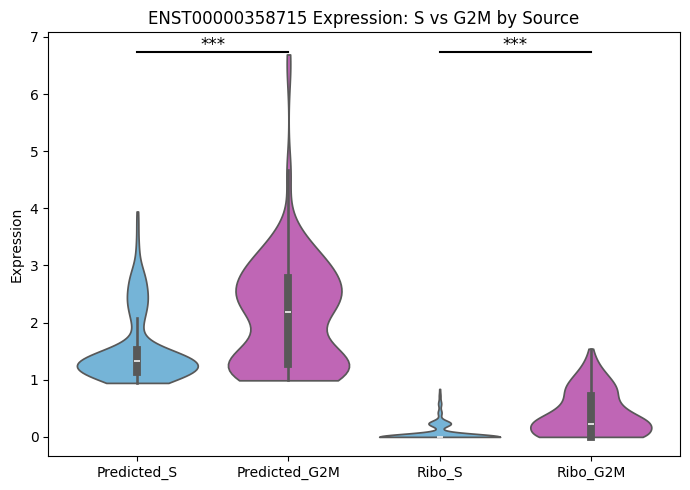

Predicted_Protein (S vs G2M): p = 8.2822e-10
RiboSeq (S vs G2M): p = 1.4803e-25


In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# 指定基因 ID
gene_id = "ENST00000358715"

# 构造表达数据
def extract_group(adata, phase, source_label, phase_label):
    expr = adata[adata.obs['phase'] == phase][:, gene_id].X.toarray().flatten()
    return pd.DataFrame({
        "Expression": expr,
        "Group": f"{source_label}_{phase_label}"
    })

# 获取数据
df_pred_s = extract_group(adata_sc1, "S", "Predicted", "S")
df_pred_g2m = extract_group(adata_sc1, "G2M", "Predicted", "G2M")
df_ribo_s = extract_group(adata_sc, "S", "Ribo", "S")
df_ribo_g2m = extract_group(adata_sc, "G2M", "Ribo", "G2M")

# 合并数据
plot_df = pd.concat([df_pred_s, df_pred_g2m, df_ribo_s, df_ribo_g2m])

# 计算 p 值和标注
def get_significance(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'

p1 = mannwhitneyu(df_pred_s["Expression"], df_pred_g2m["Expression"]).pvalue
p2 = mannwhitneyu(df_ribo_s["Expression"], df_ribo_g2m["Expression"]).pvalue
sig1 = get_significance(p1)
sig2 = get_significance(p2)

# 设置绘图顺序和颜色
order = ["Predicted_S", "Predicted_G2M", "Ribo_S", "Ribo_G2M"]
group_palette = {
    "Predicted_S": "#64B9E8",
    "Predicted_G2M": "#CE57C0",
    "Ribo_S": "#64B9E8",
    "Ribo_G2M": "#CE57C0"
}

# 绘图
plt.figure(figsize=(7, 5))
sns.violinplot(data=plot_df, x="Group", y="Expression", order=order,
               palette=group_palette, cut=0, inner="box")

# 添加显著性标注
y_max = plot_df["Expression"].max()
plt.plot([0, 1], [y_max + 0.05, y_max + 0.05], color='black')
plt.text(0.5, y_max + 0.07, sig1, ha='center', fontsize=12)

plt.plot([2, 3], [y_max + 0.05, y_max + 0.05], color='black')
plt.text(2.5, y_max + 0.07, sig2, ha='center', fontsize=12)

# 美化
plt.title(f"{gene_id} Expression: S vs G2M by Source")
plt.ylabel("Expression")
plt.xlabel("")
plt.tight_layout()
plt.show()

# 打印 p 值
print(f"Predicted_Protein (S vs G2M): p = {p1:.4e}")
print(f"RiboSeq (S vs G2M): p = {p2:.4e}")


/tmp/ipykernel_3069314/128906181.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="Group", y="Expression", order=order,


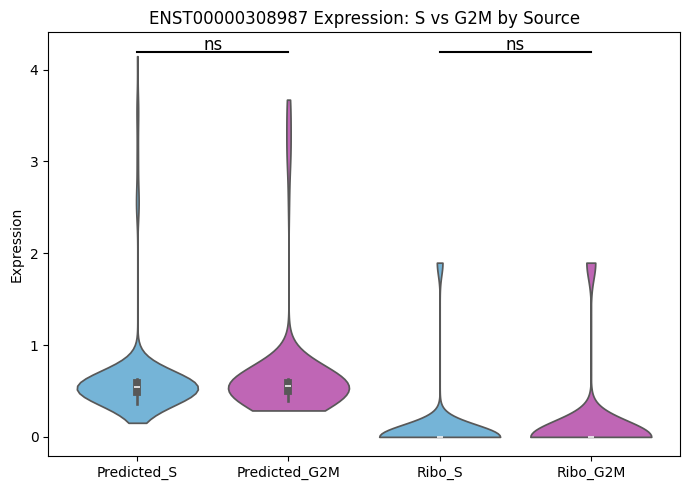

[adata_sc1] Predicted_Protein S vs G2M:
  Mann–Whitney U p = 3.4590e-01, AUC = 0.528, significance: ns
[adata_sc]  RiboSeq S vs G2M:
  Mann–Whitney U p = 3.3009e-01, AUC = 0.512, significance: ns


In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from sklearn.metrics import roc_auc_score

# 指定基因 ID
gene_id = "ENST00000308987"

# 构造表达数据
def extract_group(adata, phase, source_label, phase_label):
    expr = adata[adata.obs['phase'] == phase][:, gene_id].X.toarray().flatten()
    return pd.DataFrame({
        "Expression": expr,
        "Group": f"{source_label}_{phase_label}"
    })

# 获取数据
df_pred_s = extract_group(adata_sc1, "S", "Predicted", "S")
df_pred_g2m = extract_group(adata_sc1, "G2M", "Predicted", "G2M")
df_ribo_s = extract_group(adata_sc, "S", "Ribo", "S")
df_ribo_g2m = extract_group(adata_sc, "G2M", "Ribo", "G2M")

# 合并数据
plot_df = pd.concat([df_pred_s, df_pred_g2m, df_ribo_s, df_ribo_g2m])

# Mann–Whitney U 检验
p1 = mannwhitneyu(df_pred_s["Expression"], df_pred_g2m["Expression"]).pvalue
p2 = mannwhitneyu(df_ribo_s["Expression"], df_ribo_g2m["Expression"]).pvalue

def get_significance(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'

sig1 = get_significance(p1)
sig2 = get_significance(p2)

# ROC-AUC 分析
labels_pred = [0] * len(df_pred_s) + [1] * len(df_pred_g2m)
auc_pred = roc_auc_score(labels_pred, pd.concat([df_pred_s, df_pred_g2m])["Expression"])

labels_ribo = [0] * len(df_ribo_s) + [1] * len(df_ribo_g2m)
auc_ribo = roc_auc_score(labels_ribo, pd.concat([df_ribo_s, df_ribo_g2m])["Expression"])

# 颜色设置
order = ["Predicted_S", "Predicted_G2M", "Ribo_S", "Ribo_G2M"]
group_palette = {
    "Predicted_S": "#64B9E8",
    "Predicted_G2M": "#CE57C0",
    "Ribo_S": "#64B9E8",
    "Ribo_G2M": "#CE57C0"
}

# 绘图
plt.figure(figsize=(7, 5))
sns.violinplot(data=plot_df, x="Group", y="Expression", order=order,
               palette=group_palette, cut=0, inner="box")

# 显著性标注
y_max = plot_df["Expression"].max()
plt.plot([0, 1], [y_max + 0.05, y_max + 0.05], color='black')
plt.text(0.5, y_max + 0.07, sig1, ha='center', fontsize=12)

plt.plot([2, 3], [y_max + 0.05, y_max + 0.05], color='black')
plt.text(2.5, y_max + 0.07, sig2, ha='center', fontsize=12)

plt.title(f"{gene_id} Expression: S vs G2M by Source")
plt.ylabel("Expression")
plt.xlabel("")
plt.tight_layout()
plt.show()

# 打印结果
print(f"[adata_sc1] Predicted_Protein S vs G2M:")
print(f"  Mann–Whitney U p = {p1:.4e}, AUC = {auc_pred:.3f}, significance: {sig1}")
print(f"[adata_sc]  RiboSeq S vs G2M:")
print(f"  Mann–Whitney U p = {p2:.4e}, AUC = {auc_ribo:.3f}, significance: {sig2}")


/tmp/ipykernel_3069314/3924854535.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="Group", y="Expression", order=order,


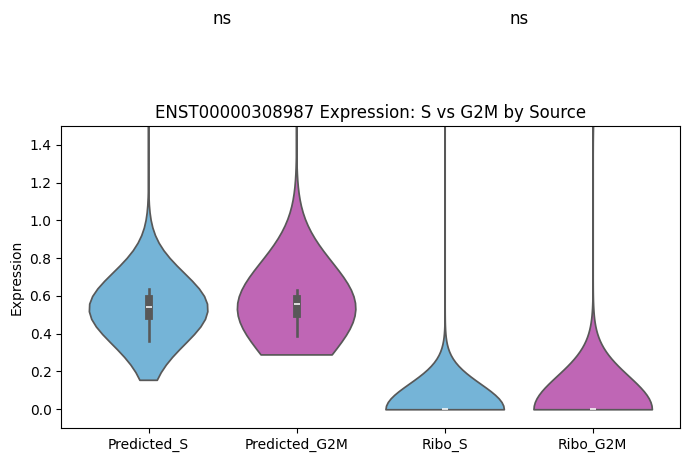

Predicted_Protein (S vs G2M) KS test: p = 3.5382e-01
RiboSeq (S vs G2M) KS test: p = 1.0000e+00


In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

# 指定基因 ID
gene_id = "ENST00000308987"

# 构造表达数据
def extract_group(adata, phase, source_label, phase_label):
    expr = adata[adata.obs['phase'] == phase][:, gene_id].X.toarray().flatten()
    return pd.DataFrame({
        "Expression": expr,
        "Group": f"{source_label}_{phase_label}"
    })

# 获取数据
df_pred_s = extract_group(adata_sc1, "S", "Predicted", "S")
df_pred_g2m = extract_group(adata_sc1, "G2M", "Predicted", "G2M")
df_ribo_s = extract_group(adata_sc, "S", "Ribo", "S")
df_ribo_g2m = extract_group(adata_sc, "G2M", "Ribo", "G2M")

# 合并数据
plot_df = pd.concat([df_pred_s, df_pred_g2m, df_ribo_s, df_ribo_g2m])

# 计算 KS 检验 p 值
from scipy.stats import ks_2samp
def get_significance(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'

p1 = ks_2samp(df_pred_s["Expression"], df_pred_g2m["Expression"]).pvalue
p2 = ks_2samp(df_ribo_s["Expression"], df_ribo_g2m["Expression"]).pvalue
sig1 = get_significance(p1)
sig2 = get_significance(p2)

# 设置绘图顺序和颜色
order = ["Predicted_S", "Predicted_G2M", "Ribo_S", "Ribo_G2M"]
group_palette = {
    "Predicted_S": "#64B9E8",
    "Predicted_G2M": "#CE57C0",
    "Ribo_S": "#64B9E8",
    "Ribo_G2M": "#CE57C0"
}

# 绘图
plt.figure(figsize=(7, 5))
sns.violinplot(data=plot_df, x="Group", y="Expression", order=order,
               palette=group_palette, cut=0, inner="box")

# 添加显著性标注
y_max = 2.0
plt.plot([0, 1], [y_max + 0.02, y_max + 0.02], color='black')
plt.text(0.5, y_max + 0.04, sig1, ha='center', fontsize=12)

plt.plot([2, 3], [y_max + 0.02, y_max + 0.02], color='black')
plt.text(2.5, y_max + 0.04, sig2, ha='center', fontsize=12)

# 设置坐标轴范围
plt.ylim(-0.1, 1.5)

# 美化
plt.title(f"{gene_id} Expression: S vs G2M by Source")
plt.ylabel("Expression")
plt.xlabel("")
plt.tight_layout()
plt.show()

# 打印 p 值
print(f"Predicted_Protein (S vs G2M) KS test: p = {p1:.4e}")
print(f"RiboSeq (S vs G2M) KS test: p = {p2:.4e}")


/tmp/ipykernel_2622209/1698383523.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="Group", y="Expression", order=order,


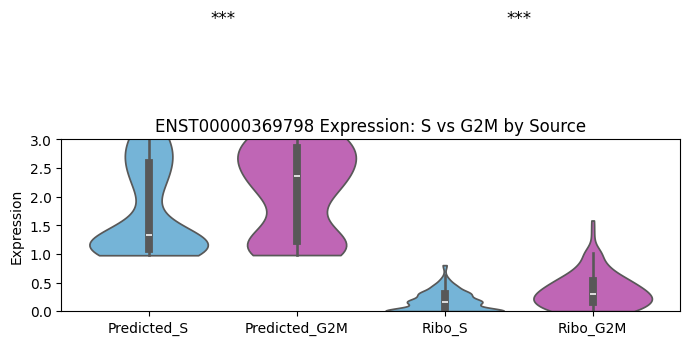

[Predicted S vs G2M]
  - Mann-Whitney U:   3.8870e-05
  - Welch t-test:     7.1417e-06
  - KS test:          6.4953e-07
  - Wilcoxon:         1.8977e-05
[RiboSeq S vs G2M]
  - Mann-Whitney U:   5.2020e-12
  - Welch t-test:     8.7099e-12
  - KS test:          2.7704e-07
  - Wilcoxon:         1.0573e-10


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, ttest_ind, ks_2samp, wilcoxon

# 指定基因 ID
gene_id = "ENST00000369798"

# 构造表达数据
def extract_group(adata, phase, source_label, phase_label):
    expr = adata[adata.obs['phase'] == phase][:, gene_id].X.toarray().flatten()
    return pd.DataFrame({
        "Expression": expr,
        "Group": f"{source_label}_{phase_label}"
    })

# 获取数据
df_pred_s = extract_group(adata_sc1, "S", "Predicted", "S")
df_pred_g2m = extract_group(adata_sc1, "G2M", "Predicted", "G2M")
df_ribo_s = extract_group(adata_sc, "S", "Ribo", "S")
df_ribo_g2m = extract_group(adata_sc, "G2M", "Ribo", "G2M")

# 合并数据
plot_df = pd.concat([df_pred_s, df_pred_g2m, df_ribo_s, df_ribo_g2m])

# 显著性标注函数
def get_significance(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'

# ========== P值计算 ==========
# Mann-Whitney U
p_mw1 = mannwhitneyu(df_pred_s["Expression"], df_pred_g2m["Expression"]).pvalue
p_mw2 = mannwhitneyu(df_ribo_s["Expression"], df_ribo_g2m["Expression"]).pvalue

# Welch's t-test
p_t1 = ttest_ind(df_pred_s["Expression"], df_pred_g2m["Expression"], equal_var=False).pvalue
p_t2 = ttest_ind(df_ribo_s["Expression"], df_ribo_g2m["Expression"], equal_var=False).pvalue

# Kolmogorov-Smirnov
p_ks1 = ks_2samp(df_pred_s["Expression"], df_pred_g2m["Expression"]).pvalue
p_ks2 = ks_2samp(df_ribo_s["Expression"], df_ribo_g2m["Expression"]).pvalue

# Wilcoxon signed-rank (取最短长度)
min_len1 = min(len(df_pred_s), len(df_pred_g2m))
min_len2 = min(len(df_ribo_s), len(df_ribo_g2m))
p_wx1 = wilcoxon(df_pred_s["Expression"][:min_len1], df_pred_g2m["Expression"][:min_len1]).pvalue
p_wx2 = wilcoxon(df_ribo_s["Expression"][:min_len2], df_ribo_g2m["Expression"][:min_len2]).pvalue

# 显著性标注
sig_mw1 = get_significance(p_mw1)
sig_mw2 = get_significance(p_mw2)

# ========== 绘图 ==========
order = ["Predicted_S", "Predicted_G2M", "Ribo_S", "Ribo_G2M"]
group_palette = {
    "Predicted_S": "#64B9E8",
    "Predicted_G2M": "#CE57C0",
    "Ribo_S": "#64B9E8",
    "Ribo_G2M": "#CE57C0"
}

plt.figure(figsize=(7, 5))
sns.violinplot(data=plot_df, x="Group", y="Expression", order=order,
               palette=group_palette, cut=0, inner="box")
plt.ylim(0, 3)

y_max = plot_df["Expression"].max()
plt.plot([0, 1], [y_max + 0.05, y_max + 0.05], color='black')
plt.text(0.5, y_max + 0.07, sig_mw1, ha='center', fontsize=12)

plt.plot([2, 3], [y_max + 0.05, y_max + 0.05], color='black')
plt.text(2.5, y_max + 0.07, sig_mw2, ha='center', fontsize=12)

plt.title(f"{gene_id} Expression: S vs G2M by Source")
plt.ylabel("Expression")
plt.xlabel("")
plt.tight_layout()
plt.show()

# ========== 输出所有方法的 p 值 ==========
print(f"[Predicted S vs G2M]")
print(f"  - Mann-Whitney U:   {p_mw1:.4e}")
print(f"  - Welch t-test:     {p_t1:.4e}")
print(f"  - KS test:          {p_ks1:.4e}")
print(f"  - Wilcoxon:         {p_wx1:.4e}")

print(f"[RiboSeq S vs G2M]")
print(f"  - Mann-Whitney U:   {p_mw2:.4e}")
print(f"  - Welch t-test:     {p_t2:.4e}")
print(f"  - KS test:          {p_ks2:.4e}")
print(f"  - Wilcoxon:         {p_wx2:.4e}")


In [31]:
from scipy.stats import ttest_ind
pval = ttest_ind(df_pred_s["Expression"], df_pred_g2m["Expression"], equal_var=False).pvalue
pval
from scipy.stats import ttest_ind
pval = ttest_ind(df_ribo_s["Expression"], df_ribo_g2m["Expression"], equal_var=False).pvalue
pval

8.709941419501028e-12

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from matplotlib import rcParams, rc

# 设置 PDF 字体为可编辑
rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype'] = 42
rc('font', family='Arial')

# 基因列表
genes = [
    'ENST00000242576',
    'ENST00000338193',
    'ENST00000622802',
    'ENST00000314103',
    'ENST00000585124',
    'ENST00000369798',
    'ENST00000358715'
]

# 提取表达数据函数
def extract_group(adata, phase, source_label, phase_label, gene_id):
    expr = adata[adata.obs['phase'] == phase][:, gene_id].X.toarray().flatten()
    return pd.DataFrame({
        "Expression": expr,
        "Group": f"{source_label}_{phase_label}"
    })

# 显著性标注
def get_significance(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'

# 循环绘图并保存
for gene_id in genes:
    try:
        # 构建数据
        df_pred_s = extract_group(adata_sc1, "S", "Predicted", "S", gene_id)
        df_pred_g2m = extract_group(adata_sc1, "G2M", "Predicted", "G2M", gene_id)
        df_ribo_s = extract_group(adata_sc, "S", "Ribo", "S", gene_id)
        df_ribo_g2m = extract_group(adata_sc, "G2M", "Ribo", "G2M", gene_id)
        plot_df = pd.concat([df_pred_s, df_pred_g2m, df_ribo_s, df_ribo_g2m])

        # Wilcoxon signed-rank test（匹配长度）
        min_len_pred = min(len(df_pred_s), len(df_pred_g2m))
        min_len_ribo = min(len(df_ribo_s), len(df_ribo_g2m))
        p1 = wilcoxon(df_pred_s["Expression"][:min_len_pred],
                      df_pred_g2m["Expression"][:min_len_pred]).pvalue
        p2 = wilcoxon(df_ribo_s["Expression"][:min_len_ribo],
                      df_ribo_g2m["Expression"][:min_len_ribo]).pvalue
        sig1 = get_significance(p1)
        sig2 = get_significance(p2)

        # 颜色和顺序
        order = ["Predicted_S", "Predicted_G2M", "Ribo_S", "Ribo_G2M"]
        group_palette = {
            "Predicted_S": "#64B9E8",
            "Predicted_G2M": "#CE57C0",
            "Ribo_S": "#64B9E8",
            "Ribo_G2M": "#CE57C0"
        }

        # 绘图
        plt.figure(figsize=(7, 5))
        sns.violinplot(data=plot_df, x="Group", y="Expression",
                       order=order, palette=group_palette,
                       cut=0, inner="box")

        # 添加显著性标注
        y_max = plot_df["Expression"].max()
        plt.plot([0, 1], [y_max + 0.05, y_max + 0.05], color='black')
        plt.text(0.5, y_max + 0.07, sig1, ha='center', fontsize=12)
        plt.plot([2, 3], [y_max + 0.05, y_max + 0.05], color='black')
        plt.text(2.5, y_max + 0.07, sig2, ha='center', fontsize=12)

        # 美化保存
        plt.title(f"{gene_id} Expression: S vs G2M by Source")
        plt.ylabel("Expression")
        plt.xlabel("")
        plt.tight_layout()
        plt.savefig(f"violin_{gene_id}.pdf", format='pdf')
        plt.close()

        print(f"{gene_id} saved.")
        print(f"  Predicted_Protein (S vs G2M): p = {p1:.4e}")
        print(f"  RiboSeq (S vs G2M): p = {p2:.4e}\n")

    except Exception as e:
        print(f"{gene_id} failed: {e}")


/tmp/ipykernel_2603995/1610741922.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="Group", y="Expression",


ENST00000242576 saved.
  Predicted_Protein (S vs G2M): p = 4.3704e-11
  RiboSeq (S vs G2M): p = 4.6993e-13



/tmp/ipykernel_2603995/1610741922.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="Group", y="Expression",


ENST00000338193 saved.
  Predicted_Protein (S vs G2M): p = 1.1573e-02
  RiboSeq (S vs G2M): p = 3.0119e-04

ENST00000622802 saved.
  Predicted_Protein (S vs G2M): p = 1.6133e-07
  RiboSeq (S vs G2M): p = 1.3594e-12



/tmp/ipykernel_2603995/1610741922.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="Group", y="Expression",
/tmp/ipykernel_2603995/1610741922.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="Group", y="Expression",


ENST00000314103 saved.
  Predicted_Protein (S vs G2M): p = 7.0406e-06
  RiboSeq (S vs G2M): p = 1.7292e-04

ENST00000585124 saved.
  Predicted_Protein (S vs G2M): p = 2.3785e-04
  RiboSeq (S vs G2M): p = 2.6956e-11



/tmp/ipykernel_2603995/1610741922.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="Group", y="Expression",
/tmp/ipykernel_2603995/1610741922.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="Group", y="Expression",


ENST00000369798 saved.
  Predicted_Protein (S vs G2M): p = 1.8977e-05
  RiboSeq (S vs G2M): p = 1.0573e-10

ENST00000358715 saved.
  Predicted_Protein (S vs G2M): p = 1.5688e-09
  RiboSeq (S vs G2M): p = 3.2001e-15



/tmp/ipykernel_2603995/1610741922.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="Group", y="Expression",


In [10]:
import pandas as pd
from scipy.stats import ttest_ind

# 基因列表
test = s_genes

# 保存符合条件的基因
selected_genes = []

# 遍历每个基因
for gene in test:
    try:
        # 提取adata1中G2M和S期的表达量
        g2m_expr_1 = adata_sc1[adata_sc1.obs['phase'] == 'G2M'][:, gene].X.toarray().flatten()
        s_expr_1 = adata_sc1[adata_sc1.obs['phase'] == 'S'][:, gene].X.toarray().flatten()
        
        # 平均表达量比较
        g2m_mean_1 = g2m_expr_1.mean()
        s_mean_1 = s_expr_1.mean()
        
        # 计算adata1中的p值
        pval_1 = ttest_ind(g2m_expr_1, s_expr_1, equal_var=False).pvalue

        # 计算adata中的p值（作为参考比较）
        g2m_expr_2 = adata_sc[adata_sc.obs['phase'] == 'G2M'][:, gene].X.toarray().flatten()
        s_expr_2 = adata_sc[adata_sc.obs['phase'] == 'S'][:, gene].X.toarray().flatten()
        pval_2 = ttest_ind(g2m_expr_2, s_expr_2, equal_var=False).pvalue

        # 条件筛选
        if g2m_mean_1 < s_mean_1 and pval_1 < pval_2:
            selected_genes.append({
                "gene": gene,
                "G2M_mean_adata1": g2m_mean_1,
                "S_mean_adata1": s_mean_1,
                "pval_adata1": pval_1,
                "pval_adata": pval_2
            })

    except Exception as e:
        print(f"{gene} skipped due to error: {e}")

# 转换为 DataFrame 查看结果
result_df = pd.DataFrame(selected_genes)
display(result_df)


,gene,G2M_mean_adata1,S_mean_adata1,pval_adata1,pval_adata
0,ENST00000323274,1.359942,1.520601,1.611621e-02,0.023832
1,ENST00000300738,2.706979,2.754963,6.489066e-01,0.654733
2,ENST00000253462,0.197461,0.291498,6.207288e-04,0.002624
3,ENST00000348459,2.619272,2.790092,9.757248e-03,0.030146
4,ENST00000373912,2.439546,2.662694,1.648087e-02,0.232519
5,ENST00000351223,2.961441,3.067946,1.939081e-01,0.852828
6,ENST00000230056,1.735573,1.896964,3.630359e-02,0.473001
7,ENST00000263681,1.490653,1.809753,5.216752e-05,0.004284
8,ENST00000641198,1.559203,1.812607,9.232867e-05,0.016609
9,ENST00000261881,0.948175,1.102907,1.293302e-02,0.053953


In [17]:
import pandas as pd
from scipy.stats import mannwhitneyu

# 基因列表
test = g2m_genes

# 保存符合条件的基因
selected_genes = []

# 遍历每个基因
for gene in test:
    try:
        # 提取 adata_sc1 中 G2M 和 S 期的表达量
        g2m_expr_1 = adata_sc1[adata_sc1.obs['phase'] == 'G2M'][:, gene].X.toarray().flatten()
        s_expr_1 = adata_sc1[adata_sc1.obs['phase'] == 'S'][:, gene].X.toarray().flatten()

        # 平均表达量比较
        g2m_mean_1 = g2m_expr_1.mean()
        s_mean_1 = s_expr_1.mean()

        # 计算 adata_sc1 中的 Mann–Whitney U 检验 p 值
        pval_1 = mannwhitneyu(g2m_expr_1, s_expr_1, alternative='two-sided').pvalue

        # 提取 adata_sc 中 G2M 和 S 期的表达量
        g2m_expr_2 = adata_sc[adata_sc.obs['phase'] == 'G2M'][:, gene].X.toarray().flatten()
        s_expr_2 = adata_sc[adata_sc.obs['phase'] == 'S'][:, gene].X.toarray().flatten()

        # 计算 adata_sc 中的 Mann–Whitney U 检验 p 值
        pval_2 = mannwhitneyu(g2m_expr_2, s_expr_2, alternative='two-sided').pvalue

        # 条件筛选
        if g2m_mean_1 > s_mean_1 and pval_1 < pval_2:
            selected_genes.append({
                "gene": gene,
                "G2M_mean_adata1": g2m_mean_1,
                "S_mean_adata1": s_mean_1,
                "pval_adata1": pval_1,
                "pval_adata": pval_2
            })

    except Exception as e:
        print(f"{gene} skipped due to error: {e}")

# 转换为 DataFrame 查看结果
result_df = pd.DataFrame(selected_genes)
display(result_df)


""


In [10]:
import pandas as pd
from scipy.stats import ks_2samp
from sklearn.utils import resample
import numpy as np

# 基因列表
test = g2m_genes

# 保存符合条件的基因
selected_genes = []

# 自定义 permutation test
def permutation_test(x, y, n_permutations=1000):
    observed_diff = abs(np.mean(x) - np.mean(y))
    combined = np.concatenate([x, y])
    count = 0
    for _ in range(n_permutations):
        np.random.shuffle(combined)
        new_x = combined[:len(x)]
        new_y = combined[len(x):]
        new_diff = abs(np.mean(new_x) - np.mean(new_y))
        if new_diff >= observed_diff:
            count += 1
    return count / n_permutations

# 遍历每个基因
for gene in test:
    try:
        # 提取 adata_sc1 中 G2M 和 S 期的表达量
        g2m_expr_1 = adata_sc1[adata_sc1.obs['phase'] == 'G2M'][:, gene].X.toarray().flatten()
        s_expr_1 = adata_sc1[adata_sc1.obs['phase'] == 'S'][:, gene].X.toarray().flatten()

        # 平均表达量比较
        g2m_mean_1 = g2m_expr_1.mean()
        s_mean_1 = s_expr_1.mean()

        # KS test p 值
        ks_pval_1 = ks_2samp(g2m_expr_1, s_expr_1).pvalue

        # permutation test p 值
        perm_pval_1 = permutation_test(g2m_expr_1, s_expr_1)

        # 提取 adata_sc 中 G2M 和 S 期的表达量
        g2m_expr_2 = adata_sc[adata_sc.obs['phase'] == 'G2M'][:, gene].X.toarray().flatten()
        s_expr_2 = adata_sc[adata_sc.obs['phase'] == 'S'][:, gene].X.toarray().flatten()

        ks_pval_2 = ks_2samp(g2m_expr_2, s_expr_2).pvalue
        perm_pval_2 = permutation_test(g2m_expr_2, s_expr_2)

        # 筛选条件：均值差异大于0 且 KS 或 permutation 的 p 值更小
        if ks_pval_1 < ks_pval_2:
            selected_genes.append({
                "gene": gene,
                "G2M_mean_adata1": g2m_mean_1,
                "S_mean_adata1": s_mean_1,
                "KS_pval_adata1": ks_pval_1,
                "KS_pval_adata": ks_pval_2,
                "Permutation_pval_adata1": perm_pval_1,
                "Permutation_pval_adata": perm_pval_2
            })

    except Exception as e:
        print(f"{gene} skipped due to error: {e}")

# 转换为 DataFrame 查看结果
result_df = pd.DataFrame(selected_genes)
display(result_df)


,gene,G2M_mean_adata1,S_mean_adata1,KS_pval_adata1,KS_pval_adata,Permutation_pval_adata1,Permutation_pval_adata
0,ENST00000308987,0.687497,0.641357,0.353817,1.000000,0.410,0.317
1,ENST00000572447,0.344487,0.301482,0.000629,0.000681,0.181,0.000
2,ENST00000411486,0.478407,0.435122,0.056237,0.116887,0.226,0.000
3,ENST00000209875,1.894748,1.879710,0.554181,0.821876,0.838,0.354


#auc更高的基因

In [19]:
from sklearn.metrics import roc_auc_score

# 保存结果
better_genes = []

for gene in g2m_genes:
    try:
        # 提取表达
        expr_pred_s = adata_sc1[adata_sc1.obs['phase'] == 'S'][:, gene].X.toarray().flatten()
        expr_pred_g2m = adata_sc1[adata_sc1.obs['phase'] == 'G2M'][:, gene].X.toarray().flatten()
        expr_ribo_s = adata_sc[adata_sc.obs['phase'] == 'S'][:, gene].X.toarray().flatten()
        expr_ribo_g2m = adata_sc[adata_sc.obs['phase'] == 'G2M'][:, gene].X.toarray().flatten()

        # 构造标签和表达
        labels_pred = [0] * len(expr_pred_s) + [1] * len(expr_pred_g2m)
        values_pred = list(expr_pred_s) + list(expr_pred_g2m)
        auc_pred = roc_auc_score(labels_pred, values_pred)

        labels_ribo = [0] * len(expr_ribo_s) + [1] * len(expr_ribo_g2m)
        values_ribo = list(expr_ribo_s) + list(expr_ribo_g2m)
        auc_ribo = roc_auc_score(labels_ribo, values_ribo)

        # 判断条件
        if auc_pred > auc_ribo:
            better_genes.append(gene)

    except Exception as e:
        print(f"{gene} skipped due to error: {e}")

# 输出基因列表
print("Genes with higher AUC in adata_sc1 than adata_sc:")
print(better_genes)


Genes with higher AUC in adata_sc1 than adata_sc:
['ENST00000308987']


/tmp/ipykernel_2707141/2483354115.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="Group", y="Expression", order=order,


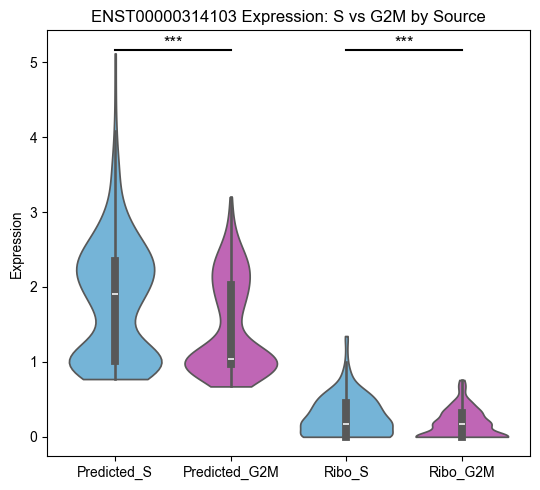

Predicted_Protein (S vs G2M): p = 7.0406e-06
RiboSeq (S vs G2M): p = 1.7292e-04


In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from matplotlib import rcParams, rc

# 设置可编辑字体（如用于 AI 或 PPT 编辑）
rcParams['pdf.fonttype'] = 42  # TrueType
rcParams['ps.fonttype'] = 42
rc('font', family='Arial')  # 也可以是 Helvetica

# 指定基因 ID
gene_id = "ENST00000314103"

# 构造表达数据
def extract_group(adata, phase, source_label, phase_label):
    expr = adata[adata.obs['phase'] == phase][:, gene_id].X.toarray().flatten()
    return pd.DataFrame({
        "Expression": expr,
        "Group": f"{source_label}_{phase_label}"
    })

# 获取数据
df_pred_s = extract_group(adata_sc1, "S", "Predicted", "S")
df_pred_g2m = extract_group(adata_sc1, "G2M", "Predicted", "G2M")
df_ribo_s = extract_group(adata_sc, "S", "Ribo", "S")
df_ribo_g2m = extract_group(adata_sc, "G2M", "Ribo", "G2M")

# 合并用于绘图
plot_df = pd.concat([df_pred_s, df_pred_g2m, df_ribo_s, df_ribo_g2m])

# 显著性标注函数
def get_significance(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'

# Wilcoxon 检验（截断长度确保配对）
min_len_pred = min(len(df_pred_s), len(df_pred_g2m))
min_len_ribo = min(len(df_ribo_s), len(df_ribo_g2m))

p1 = wilcoxon(df_pred_s["Expression"][:min_len_pred], df_pred_g2m["Expression"][:min_len_pred]).pvalue
p2 = wilcoxon(df_ribo_s["Expression"][:min_len_ribo], df_ribo_g2m["Expression"][:min_len_ribo]).pvalue
sig1 = get_significance(p1)
sig2 = get_significance(p2)

# 绘图设置
order = ["Predicted_S", "Predicted_G2M", "Ribo_S", "Ribo_G2M"]
group_palette = {
    "Predicted_S": "#64B9E8",
    "Predicted_G2M": "#CE57C0",
    "Ribo_S": "#64B9E8",
    "Ribo_G2M": "#CE57C0"
}

plt.figure(figsize=(5.5, 5))
sns.violinplot(data=plot_df, x="Group", y="Expression", order=order,
               palette=group_palette, cut=0, inner="box")

# 添加显著性线和标签
y_max = plot_df["Expression"].max()
plt.plot([0, 1], [y_max + 0.05, y_max + 0.05], color='black')
plt.text(0.5, y_max + 0.07, sig1, ha='center', fontsize=12)
plt.plot([2, 3], [y_max + 0.05, y_max + 0.05], color='black')
plt.text(2.5, y_max + 0.07, sig2, ha='center', fontsize=12)

# 图像美化
plt.title(f"{gene_id} Expression: S vs G2M by Source")
plt.ylabel("Expression")
plt.xlabel("")
plt.tight_layout()

# 保存为 PDF（可编辑字体）
plt.savefig(f"{gene_id}_expression_violinplot.pdf", format="pdf")
plt.show()

# 打印 p 值
print(f"Predicted_Protein (S vs G2M): p = {p1:.4e}")
print(f"RiboSeq (S vs G2M): p = {p2:.4e}")


/tmp/ipykernel_2707141/2083395058.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="Group", y="Expression", order=order,


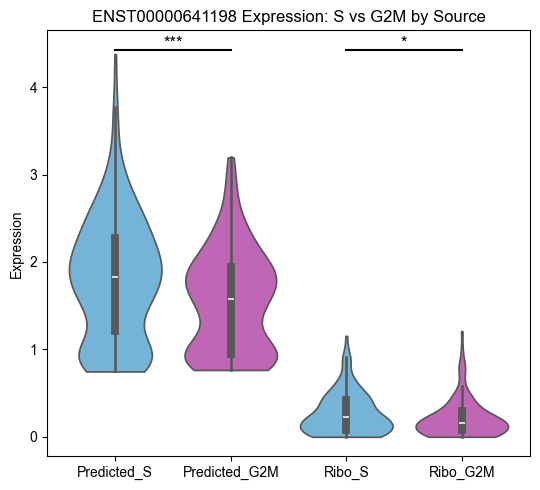

Predicted_Protein (S vs G2M): p = 3.0167e-05
RiboSeq (S vs G2M): p = 3.3936e-02


In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from matplotlib import rcParams, rc

# 设置可编辑字体（如用于 AI 或 PPT 编辑）
rcParams['pdf.fonttype'] = 42  # TrueType
rcParams['ps.fonttype'] = 42
rc('font', family='Arial')  # 也可以是 Helvetica

# 指定基因 ID
gene_id = "ENST00000641198"

# 构造表达数据
def extract_group(adata, phase, source_label, phase_label):
    expr = adata[adata.obs['phase'] == phase][:, gene_id].X.toarray().flatten()
    return pd.DataFrame({
        "Expression": expr,
        "Group": f"{source_label}_{phase_label}"
    })

# 获取数据
df_pred_s = extract_group(adata_sc1, "S", "Predicted", "S")
df_pred_g2m = extract_group(adata_sc1, "G2M", "Predicted", "G2M")
df_ribo_s = extract_group(adata_sc, "S", "Ribo", "S")
df_ribo_g2m = extract_group(adata_sc, "G2M", "Ribo", "G2M")

# 合并用于绘图
plot_df = pd.concat([df_pred_s, df_pred_g2m, df_ribo_s, df_ribo_g2m])

# 显著性标注函数
def get_significance(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'

# Wilcoxon 检验（截断长度确保配对）
min_len_pred = min(len(df_pred_s), len(df_pred_g2m))
min_len_ribo = min(len(df_ribo_s), len(df_ribo_g2m))

p1 = wilcoxon(df_pred_s["Expression"][:min_len_pred], df_pred_g2m["Expression"][:min_len_pred]).pvalue
p2 = wilcoxon(df_ribo_s["Expression"][:min_len_ribo], df_ribo_g2m["Expression"][:min_len_ribo]).pvalue
sig1 = get_significance(p1)
sig2 = get_significance(p2)

# 绘图设置
order = ["Predicted_S", "Predicted_G2M", "Ribo_S", "Ribo_G2M"]
group_palette = {
    "Predicted_S": "#64B9E8",
    "Predicted_G2M": "#CE57C0",
    "Ribo_S": "#64B9E8",
    "Ribo_G2M": "#CE57C0"
}

plt.figure(figsize=(5.5, 5))
sns.violinplot(data=plot_df, x="Group", y="Expression", order=order,
               palette=group_palette, cut=0, inner="box")

# 添加显著性线和标签
y_max = plot_df["Expression"].max()
plt.plot([0, 1], [y_max + 0.05, y_max + 0.05], color='black')
plt.text(0.5, y_max + 0.07, sig1, ha='center', fontsize=12)
plt.plot([2, 3], [y_max + 0.05, y_max + 0.05], color='black')
plt.text(2.5, y_max + 0.07, sig2, ha='center', fontsize=12)

# 图像美化
plt.title(f"{gene_id} Expression: S vs G2M by Source")
plt.ylabel("Expression")
plt.xlabel("")
plt.tight_layout()

# 保存为 PDF（可编辑字体）
plt.savefig(f"{gene_id}_expression_violinplot.pdf", format="pdf")
plt.show()

# 打印 p 值
print(f"Predicted_Protein (S vs G2M): p = {p1:.4e}")
print(f"RiboSeq (S vs G2M): p = {p2:.4e}")


/tmp/ipykernel_2707141/4095979301.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="Group", y="Expression", order=order,


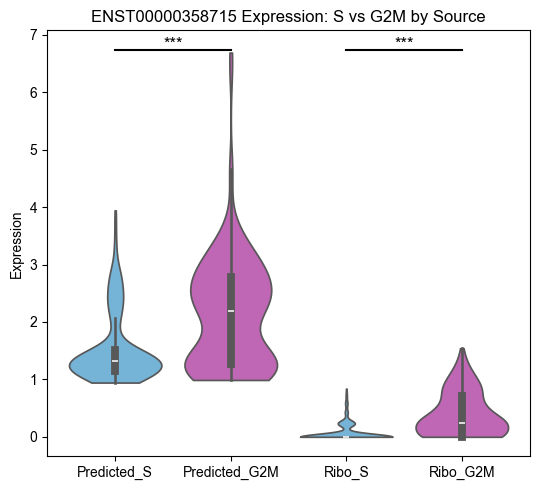

Predicted_Protein (S vs G2M): p = 1.5688e-09
RiboSeq (S vs G2M): p = 3.2001e-15


In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from matplotlib import rcParams, rc

# 设置可编辑字体（如用于 AI 或 PPT 编辑）
rcParams['pdf.fonttype'] = 42  # TrueType
rcParams['ps.fonttype'] = 42
rc('font', family='Arial')  # 也可以是 Helvetica

# 指定基因 ID
gene_id = "ENST00000358715"

# 构造表达数据
def extract_group(adata, phase, source_label, phase_label):
    expr = adata[adata.obs['phase'] == phase][:, gene_id].X.toarray().flatten()
    return pd.DataFrame({
        "Expression": expr,
        "Group": f"{source_label}_{phase_label}"
    })

# 获取数据
df_pred_s = extract_group(adata_sc1, "S", "Predicted", "S")
df_pred_g2m = extract_group(adata_sc1, "G2M", "Predicted", "G2M")
df_ribo_s = extract_group(adata_sc, "S", "Ribo", "S")
df_ribo_g2m = extract_group(adata_sc, "G2M", "Ribo", "G2M")

# 合并用于绘图
plot_df = pd.concat([df_pred_s, df_pred_g2m, df_ribo_s, df_ribo_g2m])

# 显著性标注函数
def get_significance(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'

# Wilcoxon 检验（截断长度确保配对）
min_len_pred = min(len(df_pred_s), len(df_pred_g2m))
min_len_ribo = min(len(df_ribo_s), len(df_ribo_g2m))

p1 = wilcoxon(df_pred_s["Expression"][:min_len_pred], df_pred_g2m["Expression"][:min_len_pred]).pvalue
p2 = wilcoxon(df_ribo_s["Expression"][:min_len_ribo], df_ribo_g2m["Expression"][:min_len_ribo]).pvalue
sig1 = get_significance(p1)
sig2 = get_significance(p2)

# 绘图设置
order = ["Predicted_S", "Predicted_G2M", "Ribo_S", "Ribo_G2M"]
group_palette = {
    "Predicted_S": "#64B9E8",
    "Predicted_G2M": "#CE57C0",
    "Ribo_S": "#64B9E8",
    "Ribo_G2M": "#CE57C0"
}

plt.figure(figsize=(5.5, 5))
sns.violinplot(data=plot_df, x="Group", y="Expression", order=order,
               palette=group_palette, cut=0, inner="box")

# 添加显著性线和标签
y_max = plot_df["Expression"].max()
plt.plot([0, 1], [y_max + 0.05, y_max + 0.05], color='black')
plt.text(0.5, y_max + 0.07, sig1, ha='center', fontsize=12)
plt.plot([2, 3], [y_max + 0.05, y_max + 0.05], color='black')
plt.text(2.5, y_max + 0.07, sig2, ha='center', fontsize=12)

# 图像美化
plt.title(f"{gene_id} Expression: S vs G2M by Source")
plt.ylabel("Expression")
plt.xlabel("")
plt.tight_layout()

# 保存为 PDF（可编辑字体）
plt.savefig(f"{gene_id}_expression_violinplot.pdf", format="pdf")
plt.show()

# 打印 p 值
print(f"Predicted_Protein (S vs G2M): p = {p1:.4e}")
print(f"RiboSeq (S vs G2M): p = {p2:.4e}")


/tmp/ipykernel_2707141/1381671922.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="Group", y="Expression", order=order,


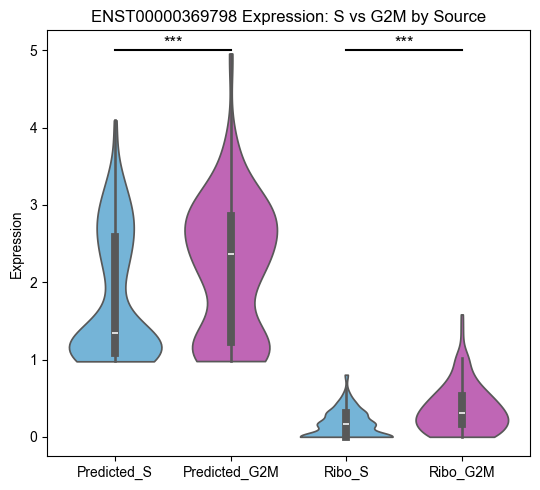

Predicted_Protein (S vs G2M): p = 1.8977e-05
RiboSeq (S vs G2M): p = 1.0573e-10


In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from matplotlib import rcParams, rc

# 设置可编辑字体（如用于 AI 或 PPT 编辑）
rcParams['pdf.fonttype'] = 42  # TrueType
rcParams['ps.fonttype'] = 42
rc('font', family='Arial')  # 也可以是 Helvetica

# 指定基因 ID
gene_id = "ENST00000369798"

# 构造表达数据
def extract_group(adata, phase, source_label, phase_label):
    expr = adata[adata.obs['phase'] == phase][:, gene_id].X.toarray().flatten()
    return pd.DataFrame({
        "Expression": expr,
        "Group": f"{source_label}_{phase_label}"
    })

# 获取数据
df_pred_s = extract_group(adata_sc1, "S", "Predicted", "S")
df_pred_g2m = extract_group(adata_sc1, "G2M", "Predicted", "G2M")
df_ribo_s = extract_group(adata_sc, "S", "Ribo", "S")
df_ribo_g2m = extract_group(adata_sc, "G2M", "Ribo", "G2M")

# 合并用于绘图
plot_df = pd.concat([df_pred_s, df_pred_g2m, df_ribo_s, df_ribo_g2m])

# 显著性标注函数
def get_significance(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'

# Wilcoxon 检验（截断长度确保配对）
min_len_pred = min(len(df_pred_s), len(df_pred_g2m))
min_len_ribo = min(len(df_ribo_s), len(df_ribo_g2m))

p1 = wilcoxon(df_pred_s["Expression"][:min_len_pred], df_pred_g2m["Expression"][:min_len_pred]).pvalue
p2 = wilcoxon(df_ribo_s["Expression"][:min_len_ribo], df_ribo_g2m["Expression"][:min_len_ribo]).pvalue
sig1 = get_significance(p1)
sig2 = get_significance(p2)

# 绘图设置
order = ["Predicted_S", "Predicted_G2M", "Ribo_S", "Ribo_G2M"]
group_palette = {
    "Predicted_S": "#64B9E8",
    "Predicted_G2M": "#CE57C0",
    "Ribo_S": "#64B9E8",
    "Ribo_G2M": "#CE57C0"
}

plt.figure(figsize=(5.5, 5))
sns.violinplot(data=plot_df, x="Group", y="Expression", order=order,
               palette=group_palette, cut=0, inner="box")

# 添加显著性线和标签
y_max = plot_df["Expression"].max()
plt.plot([0, 1], [y_max + 0.05, y_max + 0.05], color='black')
plt.text(0.5, y_max + 0.07, sig1, ha='center', fontsize=12)
plt.plot([2, 3], [y_max + 0.05, y_max + 0.05], color='black')
plt.text(2.5, y_max + 0.07, sig2, ha='center', fontsize=12)

# 图像美化
plt.title(f"{gene_id} Expression: S vs G2M by Source")
plt.ylabel("Expression")
plt.xlabel("")
plt.tight_layout()

# 保存为 PDF（可编辑字体）
plt.savefig(f"{gene_id}_expression_violinplot.pdf", format="pdf")
plt.show()

# 打印 p 值
print(f"Predicted_Protein (S vs G2M): p = {p1:.4e}")
print(f"RiboSeq (S vs G2M): p = {p2:.4e}")


/tmp/ipykernel_2707141/1799223309.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="Group", y="Expression", order=order,


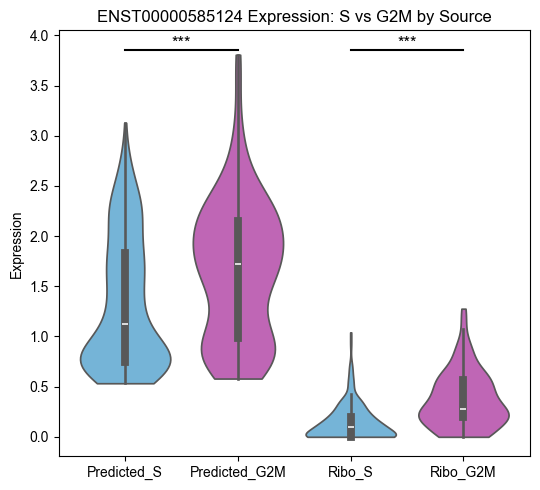

Predicted_Protein (S vs G2M): p = 2.3785e-04
RiboSeq (S vs G2M): p = 2.6956e-11


In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from matplotlib import rcParams, rc

# 设置可编辑字体（如用于 AI 或 PPT 编辑）
rcParams['pdf.fonttype'] = 42  # TrueType
rcParams['ps.fonttype'] = 42
rc('font', family='Arial')  # 也可以是 Helvetica

# 指定基因 ID
gene_id = "ENST00000585124"

# 构造表达数据
def extract_group(adata, phase, source_label, phase_label):
    expr = adata[adata.obs['phase'] == phase][:, gene_id].X.toarray().flatten()
    return pd.DataFrame({
        "Expression": expr,
        "Group": f"{source_label}_{phase_label}"
    })

# 获取数据
df_pred_s = extract_group(adata_sc1, "S", "Predicted", "S")
df_pred_g2m = extract_group(adata_sc1, "G2M", "Predicted", "G2M")
df_ribo_s = extract_group(adata_sc, "S", "Ribo", "S")
df_ribo_g2m = extract_group(adata_sc, "G2M", "Ribo", "G2M")

# 合并用于绘图
plot_df = pd.concat([df_pred_s, df_pred_g2m, df_ribo_s, df_ribo_g2m])

# 显著性标注函数
def get_significance(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'

# Wilcoxon 检验（截断长度确保配对）
min_len_pred = min(len(df_pred_s), len(df_pred_g2m))
min_len_ribo = min(len(df_ribo_s), len(df_ribo_g2m))

p1 = wilcoxon(df_pred_s["Expression"][:min_len_pred], df_pred_g2m["Expression"][:min_len_pred]).pvalue
p2 = wilcoxon(df_ribo_s["Expression"][:min_len_ribo], df_ribo_g2m["Expression"][:min_len_ribo]).pvalue
sig1 = get_significance(p1)
sig2 = get_significance(p2)

# 绘图设置
order = ["Predicted_S", "Predicted_G2M", "Ribo_S", "Ribo_G2M"]
group_palette = {
    "Predicted_S": "#64B9E8",
    "Predicted_G2M": "#CE57C0",
    "Ribo_S": "#64B9E8",
    "Ribo_G2M": "#CE57C0"
}

plt.figure(figsize=(5.5, 5))
sns.violinplot(data=plot_df, x="Group", y="Expression", order=order,
               palette=group_palette, cut=0, inner="box")

# 添加显著性线和标签
y_max = plot_df["Expression"].max()
plt.plot([0, 1], [y_max + 0.05, y_max + 0.05], color='black')
plt.text(0.5, y_max + 0.07, sig1, ha='center', fontsize=12)
plt.plot([2, 3], [y_max + 0.05, y_max + 0.05], color='black')
plt.text(2.5, y_max + 0.07, sig2, ha='center', fontsize=12)

# 图像美化
plt.title(f"{gene_id} Expression: S vs G2M by Source")
plt.ylabel("Expression")
plt.xlabel("")
plt.tight_layout()

# 保存为 PDF（可编辑字体）
plt.savefig(f"{gene_id}_expression_violinplot.pdf", format="pdf")
plt.show()

# 打印 p 值
print(f"Predicted_Protein (S vs G2M): p = {p1:.4e}")
print(f"RiboSeq (S vs G2M): p = {p2:.4e}")


/tmp/ipykernel_2459609/304102110.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="Group", y="Expression", order=order,


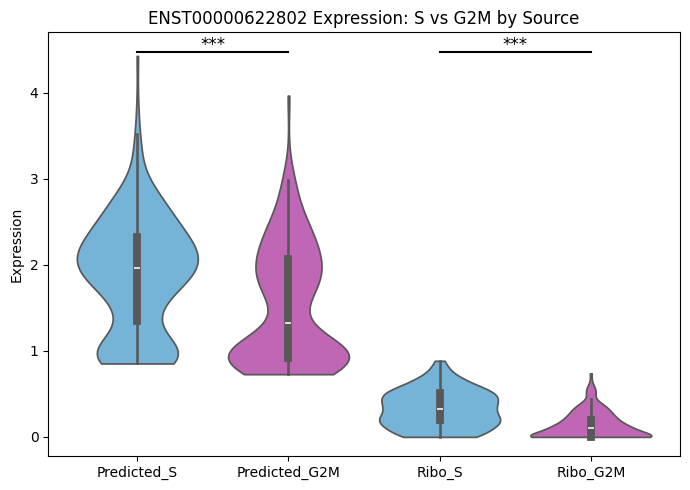

Predicted_Protein (S vs G2M): p = 1.6133e-07
RiboSeq (S vs G2M): p = 1.3594e-12


In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

# 指定基因 ID
gene_id = "ENST00000622802"

# 构造表达数据
def extract_group(adata, phase, source_label, phase_label):
    expr = adata[adata.obs['phase'] == phase][:, gene_id].X.toarray().flatten()
    return pd.DataFrame({
        "Expression": expr,
        "Group": f"{source_label}_{phase_label}"
    })

# 获取数据
df_pred_s = extract_group(adata_sc1, "S", "Predicted", "S")
df_pred_g2m = extract_group(adata_sc1, "G2M", "Predicted", "G2M")
df_ribo_s = extract_group(adata_sc, "S", "Ribo", "S")
df_ribo_g2m = extract_group(adata_sc, "G2M", "Ribo", "G2M")

# 合并用于绘图
plot_df = pd.concat([df_pred_s, df_pred_g2m, df_ribo_s, df_ribo_g2m])

# 显著性标注函数
def get_significance(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'

# Wilcoxon signed-rank test（自动取相同长度以保证配对）
min_len_pred = min(len(df_pred_s), len(df_pred_g2m))
min_len_ribo = min(len(df_ribo_s), len(df_ribo_g2m))

p1 = wilcoxon(df_pred_s["Expression"][:min_len_pred], df_pred_g2m["Expression"][:min_len_pred]).pvalue
p2 = wilcoxon(df_ribo_s["Expression"][:min_len_ribo], df_ribo_g2m["Expression"][:min_len_ribo]).pvalue
sig1 = get_significance(p1)
sig2 = get_significance(p2)

# 设置绘图顺序和颜色
order = ["Predicted_S", "Predicted_G2M", "Ribo_S", "Ribo_G2M"]
group_palette = {
    "Predicted_S": "#64B9E8",
    "Predicted_G2M": "#CE57C0",
    "Ribo_S": "#64B9E8",
    "Ribo_G2M": "#CE57C0"
}

# 绘图
plt.figure(figsize=(7, 5))
sns.violinplot(data=plot_df, x="Group", y="Expression", order=order,
               palette=group_palette, cut=0, inner="box")

# 添加显著性标注
y_max = plot_df["Expression"].max()
plt.plot([0, 1], [y_max + 0.05, y_max + 0.05], color='black')
plt.text(0.5, y_max + 0.07, sig1, ha='center', fontsize=12)

plt.plot([2, 3], [y_max + 0.05, y_max + 0.05], color='black')
plt.text(2.5, y_max + 0.07, sig2, ha='center', fontsize=12)

# 美化
plt.title(f"{gene_id} Expression: S vs G2M by Source")
plt.ylabel("Expression")
plt.xlabel("")
plt.tight_layout()
plt.show()

# 打印 p 值
print(f"Predicted_Protein (S vs G2M): p = {p1:.4e}")
print(f"RiboSeq (S vs G2M): p = {p2:.4e}")


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from matplotlib import rcParams
from matplotlib import rc

# 设置全局字体为嵌入式可编辑字体（如 Helvetica、Arial、Times）
rcParams['pdf.fonttype'] = 42  # 使用 TrueType 字体
rcParams['ps.fonttype'] = 42
rc('font', family='Arial')  # 你也可以用 'Helvetica', 'Times New Roman' 等系统字体

# 基因列表
genes = [
    'ENST00000242576',
    'ENST00000338193',
    'ENST00000622802',
    'ENST00000314103',
    'ENST00000585124',
    'ENST00000369798',
    'ENST00000358715'
]

# 提取表达数据函数
def extract_expr(adata, phase, label, gene_id):
    expr = adata[adata.obs['phase'] == phase][:, gene_id].X.toarray().flatten()
    return pd.DataFrame({
        "Expression": expr,
        "Phase": phase,
        "Source": label
    })

# 显著性符号函数
def get_significance(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'

# 绘图循环
for gene_id in genes:
    try:
        # 构造表达数据
        s_df1 = extract_expr(adata_sc1, "S", "Predicted_Protein", gene_id)
        s_df2 = extract_expr(adata_sc, "S", "RiboSeq", gene_id)
        g_df1 = extract_expr(adata_sc1, "G2M", "Predicted_Protein", gene_id)
        g_df2 = extract_expr(adata_sc, "G2M", "RiboSeq", gene_id)

        plot_df = pd.concat([s_df1, s_df2, g_df1, g_df2])

        # 计算 p 值
        s_p = ttest_ind(s_df1['Expression'], s_df2['Expression'], equal_var=False).pvalue
        g_p = ttest_ind(g_df1['Expression'], g_df2['Expression'], equal_var=False).pvalue
        s_signif = get_significance(s_p)
        g_signif = get_significance(g_p)

        # 小提琴图绘制
        plt.figure(figsize=(6, 5))
        sns.violinplot(data=plot_df, x="Phase", y="Expression", hue="Source",
                       palette={"Predicted_Protein": "#72B7DD", "RiboSeq": "#C67BBF"},
                       cut=0, inner="box")

        y_max = plot_df["Expression"].max()
        plt.plot([-0.2, 0.2], [y_max + 0.05, y_max + 0.05], color="black")
        plt.text(0, y_max + 0.07, s_signif, ha="center", fontsize=12)

        plt.plot([0.8, 1.2], [y_max + 0.05, y_max + 0.05], color="black")
        plt.text(1, y_max + 0.07, g_signif, ha="center", fontsize=12)

        plt.title(f"{gene_id} Expression in S and G2M Phase")
        plt.xlabel("Phase")
        plt.ylabel("Expression")
        plt.legend(title="Source")
        plt.tight_layout()

        # 保存为 PDF，插入可编辑字体
        plt.savefig(f"riboseqfigure6_{gene_id}_violinplot.pdf", format='pdf')
        plt.close()

        print(f"{gene_id} saved. S p-value: {s_p:.4e}, G2M p-value: {g_p:.4e}\n")

    except Exception as e:
        print(f"{gene_id} failed: {e}")


ENST00000242576 saved. S p-value: 5.1095e-94, G2M p-value: 4.8423e-53

ENST00000338193 saved. S p-value: 2.4008e-49, G2M p-value: 6.1657e-23

ENST00000622802 saved. S p-value: 3.1743e-115, G2M p-value: 3.1038e-59

ENST00000314103 saved. S p-value: 2.5203e-95, G2M p-value: 6.4165e-61

ENST00000585124 saved. S p-value: 6.6757e-89, G2M p-value: 5.9149e-55

ENST00000369798 saved. S p-value: 5.1440e-97, G2M p-value: 7.4095e-63

ENST00000358715 saved. S p-value: 9.7223e-119, G2M p-value: 7.2632e-52

